# Global sedimentary basins: inventory, thickness, and paleogeographic reconstruction

**Cluster H: Sedimentary basins.**  *Datasets:* Evenick (2021) global sedimentary basin compilation (768 basins), Bird & Mooney (2026) GST-1 sediment thickness, Afonso et al. (2019) global crustal thickness.

**A note on data provenance:** this notebook's workflow builds on the ICONS (IntraCONtinental basinS) Atlas infrastructure originally developed by Christian Heine and the EarthByte Group (Heine 2007; Heine & Müller 2008) — the original ICONS Atlas remains live at https://www.earthbyte.org/Resources/ICONS/ . The basin-polygon layer that infrastructure originally displayed came from elsewhere and is no longer used here: the basin polygons below are Evenick (2021)'s independently-sourced, verbatim-redistributed global compilation (see `data/evenick_2021_basins/README.md` for full provenance and license terms).

## What this notebook produces

1. **Present-day inventory map** of every sedimentary basin in Evenick's (2021) 768-basin global compilation, coloured by maximum sedimentary fill thickness (km).
2. **Sediment-thickness raster** (Bird & Mooney 2026 GST-1, 0.125° global) with the basin polygons overlain — visually confirms that the thickest sediment cover is inside the mapped basins.
3. **Crustal-thickness raster** (Afonso et al. 2019, 0.25° global) with the basin polygons overlain — most extensional basins sit on markedly thinned continental crust.
4. **Per-basin summary table** with both grids sampled inside each polygon, cross-validated against Evenick's own reported sediment-thickness statistics.
5. **Basin-type / regional breakdown** and an **evaporite (salt) basin analysis** built from Evenick's supplementary evaporite-occurrence spreadsheet.
6. **Paleogeographic reconstruction** of basin centroids at a user-chosen deep-time age, plus a runtime-generated `pygplates` "Basin"-type feature collection (`.gpmlz`) with reconstruction plate IDs assigned from the plate model's static polygons.

## Learning objectives

- Load a global sedimentary-basin polygon layer with `geopandas`.
- Rasterise a large sediment-thickness compilation for pyGMT rendering.
- Use a zonal-mean helper to sample a raster inside every polygon of a shapefile, and cross-validate the result against independently reported statistics.
- Compute a first-order stretching-factor proxy (`sed / crust`) from bundled global grids.
- Join a shapefile against a supplementary spreadsheet on a shared ID column (basin evaporite occurrences).
- Assign reconstruction plate IDs to polygons via the canonical `PlatePartitioner` + `StaticPolygons` pattern, build `pygplates.Feature` objects with GPGIM feature type `Basin`, and write/read a `.gpmlz` feature collection.
- Reconstruct polygon centroids to a paleo age via `gplately.Points` and overlay them on a paleogeographic map.

## Prerequisites and runtime

- **Plate model**: Merdith 2021 in paleomag frame (matches this notebook's default paleo-age conventions). Any paleomag-frame model works via `MODEL_NAME`.
- **Data (bundled, git-tracked)**: `data/evenick_2021_basins/Evenick2021_GlobalBasins.shp` (768 basins) and `Evenick2021_mmc1_evaporite_list.xlsx`, redistributed **verbatim** from Evenick (2021)'s supplementary material under **CC BY-NC-ND 4.0** — see `data/evenick_2021_basins/README.md` for full provenance and license terms. Because the license prohibits redistributing *derivative* works, the GPML conversion and plate-ID assignment below are generated fresh every time this notebook runs; no pre-converted basin file is redistributed with the tutorial suite.
- **Data (Zenodo companion archive, not GitHub-tracked)**: `data/sediment_thickness_bird_mooney/Bird_Mooney_GST14_WGS84.nc` (8 MB, 0.125°), `data/crustal_thickness_afonso/crustal-thickness-gmt-surface.nc` (4 MB, 0.25°). Both excluded from the git repo (see `.gitignore`) and ship only in the suite's Zenodo companion archive — set `ZENODO_SEDTHICK_DIR` / `ZENODO_CRUSTTHICK_DIR` if your local layout differs from the default `zenodo_data/...` paths.
- **Python**: `gplately`, `pygmt`, `pygplates`, `geopandas`, `shapely`, `xarray`, `numpy`, `pandas`, `openpyxl` (for the evaporite spreadsheet).
- **Runtime**: ~2–3 minutes (dominated by the per-basin zonal-mean sampling of the 0.125° sediment grid and the polygon plate-ID assignment).


## Environment + imports


In [1]:
from pathlib import Path
import os, sys, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, gpd, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.11.15
  numpy       2.4.4
  pandas      3.0.2
  xarray      2026.7.0
  geopandas   1.1.4
  pygmt       v0.17.0
  gplately    2.0.0
  pygplates   1.0.0


## Configuration


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME             = "Merdith2021"
ANCHOR_PLATE_ID        = 0                # Merdith2021 default rotation = paleomag frame

# Paleo age at which basin centroids are reconstructed on the paleogeographic map.
PALEO_AGE_MA           = 200.0            # Early Jurassic — Pangea breakup context

# Basin polygons — Evenick (2021), redistributed verbatim (CC BY-NC-ND 4.0),
# git-tracked directly in this repo. See data/evenick_2021_basins/README.md.
BASINS_SHP              = Path("data/evenick_2021_basins/Evenick2021_GlobalBasins.shp")
EVAPORITE_XLSX           = Path("data/evenick_2021_basins/Evenick2021_mmc1_evaporite_list.xlsx")

# Sediment/crustal thickness grids — large, Zenodo companion archive only.
SED_THK_NC             = Path(os.environ.get("ZENODO_SEDTHICK_DIR", "zenodo_data/sediment_thickness_BirdMooney")) / "Bird_Mooney_GST14_WGS84.nc"
CRUST_THK_NC           = Path(os.environ.get("ZENODO_CRUSTTHICK_DIR", "zenodo_data/crustal_thickness_Afonso")) / "crustal-thickness-gmt-surface.nc"

# Output — the Basin-type .gpmlz feature collection is BUILT AND WRITTEN AT
# RUNTIME by §9 below (never redistributed pre-built; see the license note
# in the introduction cell).
BASINS_GPMLZ_OUT        = Path("outputs/T53_evenick_basins.gpmlz")

# Map layout.
REGION, PROJ           = [-180, 180, -75, 80], "R0/22c"     # Winkel Tripel, 22 cm wide
# ============================================================================
print(f"  plate model:      {MODEL_NAME}  (anchor {ANCHOR_PLATE_ID})")
print(f"  paleo age:        {PALEO_AGE_MA:.0f} Ma")
print(f"  basins shp:       {BASINS_SHP}")
print(f"  evaporite xlsx:   {EVAPORITE_XLSX}")
print(f"  sediment grid:    {SED_THK_NC}")
print(f"  crust grid:       {CRUST_THK_NC}")
print(f"  gpmlz output:     {BASINS_GPMLZ_OUT}")


  plate model:      Merdith2021  (anchor 0)
  paleo age:        200 Ma
  basins shp:       data/evenick_2021_basins/Evenick2021_GlobalBasins.shp
  evaporite xlsx:   data/evenick_2021_basins/Evenick2021_mmc1_evaporite_list.xlsx
  sediment grid:    /home/claude/exec_repo/data/sediment_thickness_bird_mooney/Bird_Mooney_GST14_WGS84.nc
  crust grid:       /home/claude/exec_repo/data/crustal_thickness_afonso/crustal-thickness-gmt-surface.nc
  gpmlz output:     outputs/T53_evenick_basins.gpmlz


## 1. Load basin polygons + sediment and crustal thickness grids


In [3]:
basins = gpd.read_file(BASINS_SHP)
print(f"  {len(basins)} basins in the Evenick (2021) global compilation")
print(f"  columns: {list(basins.columns)}")
print(f"  Max Sed St range: {basins['Max Sed St'].min():.2f}–{basins['Max Sed St'].max():.2f} km "
      f"({basins['Max Sed St'].isna().sum()} basins unreported)")

sed_da = xr.open_dataarray(SED_THK_NC)
print(f"\n  sediment grid: {sed_da.shape}, extent {sed_da.lon.min().item():.1f} to "
      f"{sed_da.lon.max().item():.1f} lon, {sed_da.lat.min().item():.1f} to {sed_da.lat.max().item():.1f} lat")
print(f"  sediment thickness range: 0 – {int(sed_da.max())} m")

crust_ds = xr.open_dataset(CRUST_THK_NC)
crust_da = crust_ds["z"] if "z" in crust_ds else list(crust_ds.data_vars.values())[0]
if "lon" not in crust_da.dims:
    crust_da = crust_da.rename({d: d.lower() for d in crust_da.dims
                                 if d.lower() in ("lon", "lat")})
# Afonso 2019 NC stores crustal thickness in METRES — convert to km for
# downstream β and per-basin reporting.
crust_da = crust_da / 1000.0
crust_da.attrs["units"] = "km"
print(f"\n  crustal thickness grid: {crust_da.shape}")
print(f"  crustal thickness range: {float(crust_da.min()):.1f} – {float(crust_da.max()):.1f} km")


  768 basins in the Evenick (2021) global compilation
  columns: ['Basin Name', 'Polygon', 'Split Poly', 'Basin UBI', 'Longitude', 'Latitude', 'Basin Type', 'Salt', 'Volcanics', 'Region', 'Countries', 'Setting', 'Geo Period', 'Geo Age', 'Age Old', 'Age Young', 'Max Sed St', 'Mean Sed S', 'Med Sed St', 'Mean Sed L', 'Med Sed La', 'Max Sed La', 'Poly Area', 'Moho Mean', 'Moho Med k', 'Moho Max k', 'Moho Min k', 'Perm Salt', 'Tri Salt', 'Jur Salt', 'Cret Salt', 'Salt Fm(s)', 'Salt Per.', 'Salt Ages', 'Evap Numb', 'geometry']
  Max Sed St range: 0.01–18.33 km (341 basins unreported)

  sediment grid: (1441, 2881), extent -180.0 to 180.0 lon, -90.0 to 90.0 lat


  sediment thickness range: 0 – 20118 m

  crustal thickness grid: (721, 1441)
  crustal thickness range: 0.0 – 75.3 km


## 2. Panel A — modern-day inventory map: basins coloured by maximum sedimentary fill (km)

  12 basins exceed the 15 km cap and saturate at the top-end colour (see +ef overflow arrow on colourbar)
  341 basins have no reported Max Sed St and are drawn as 0 km (pale)


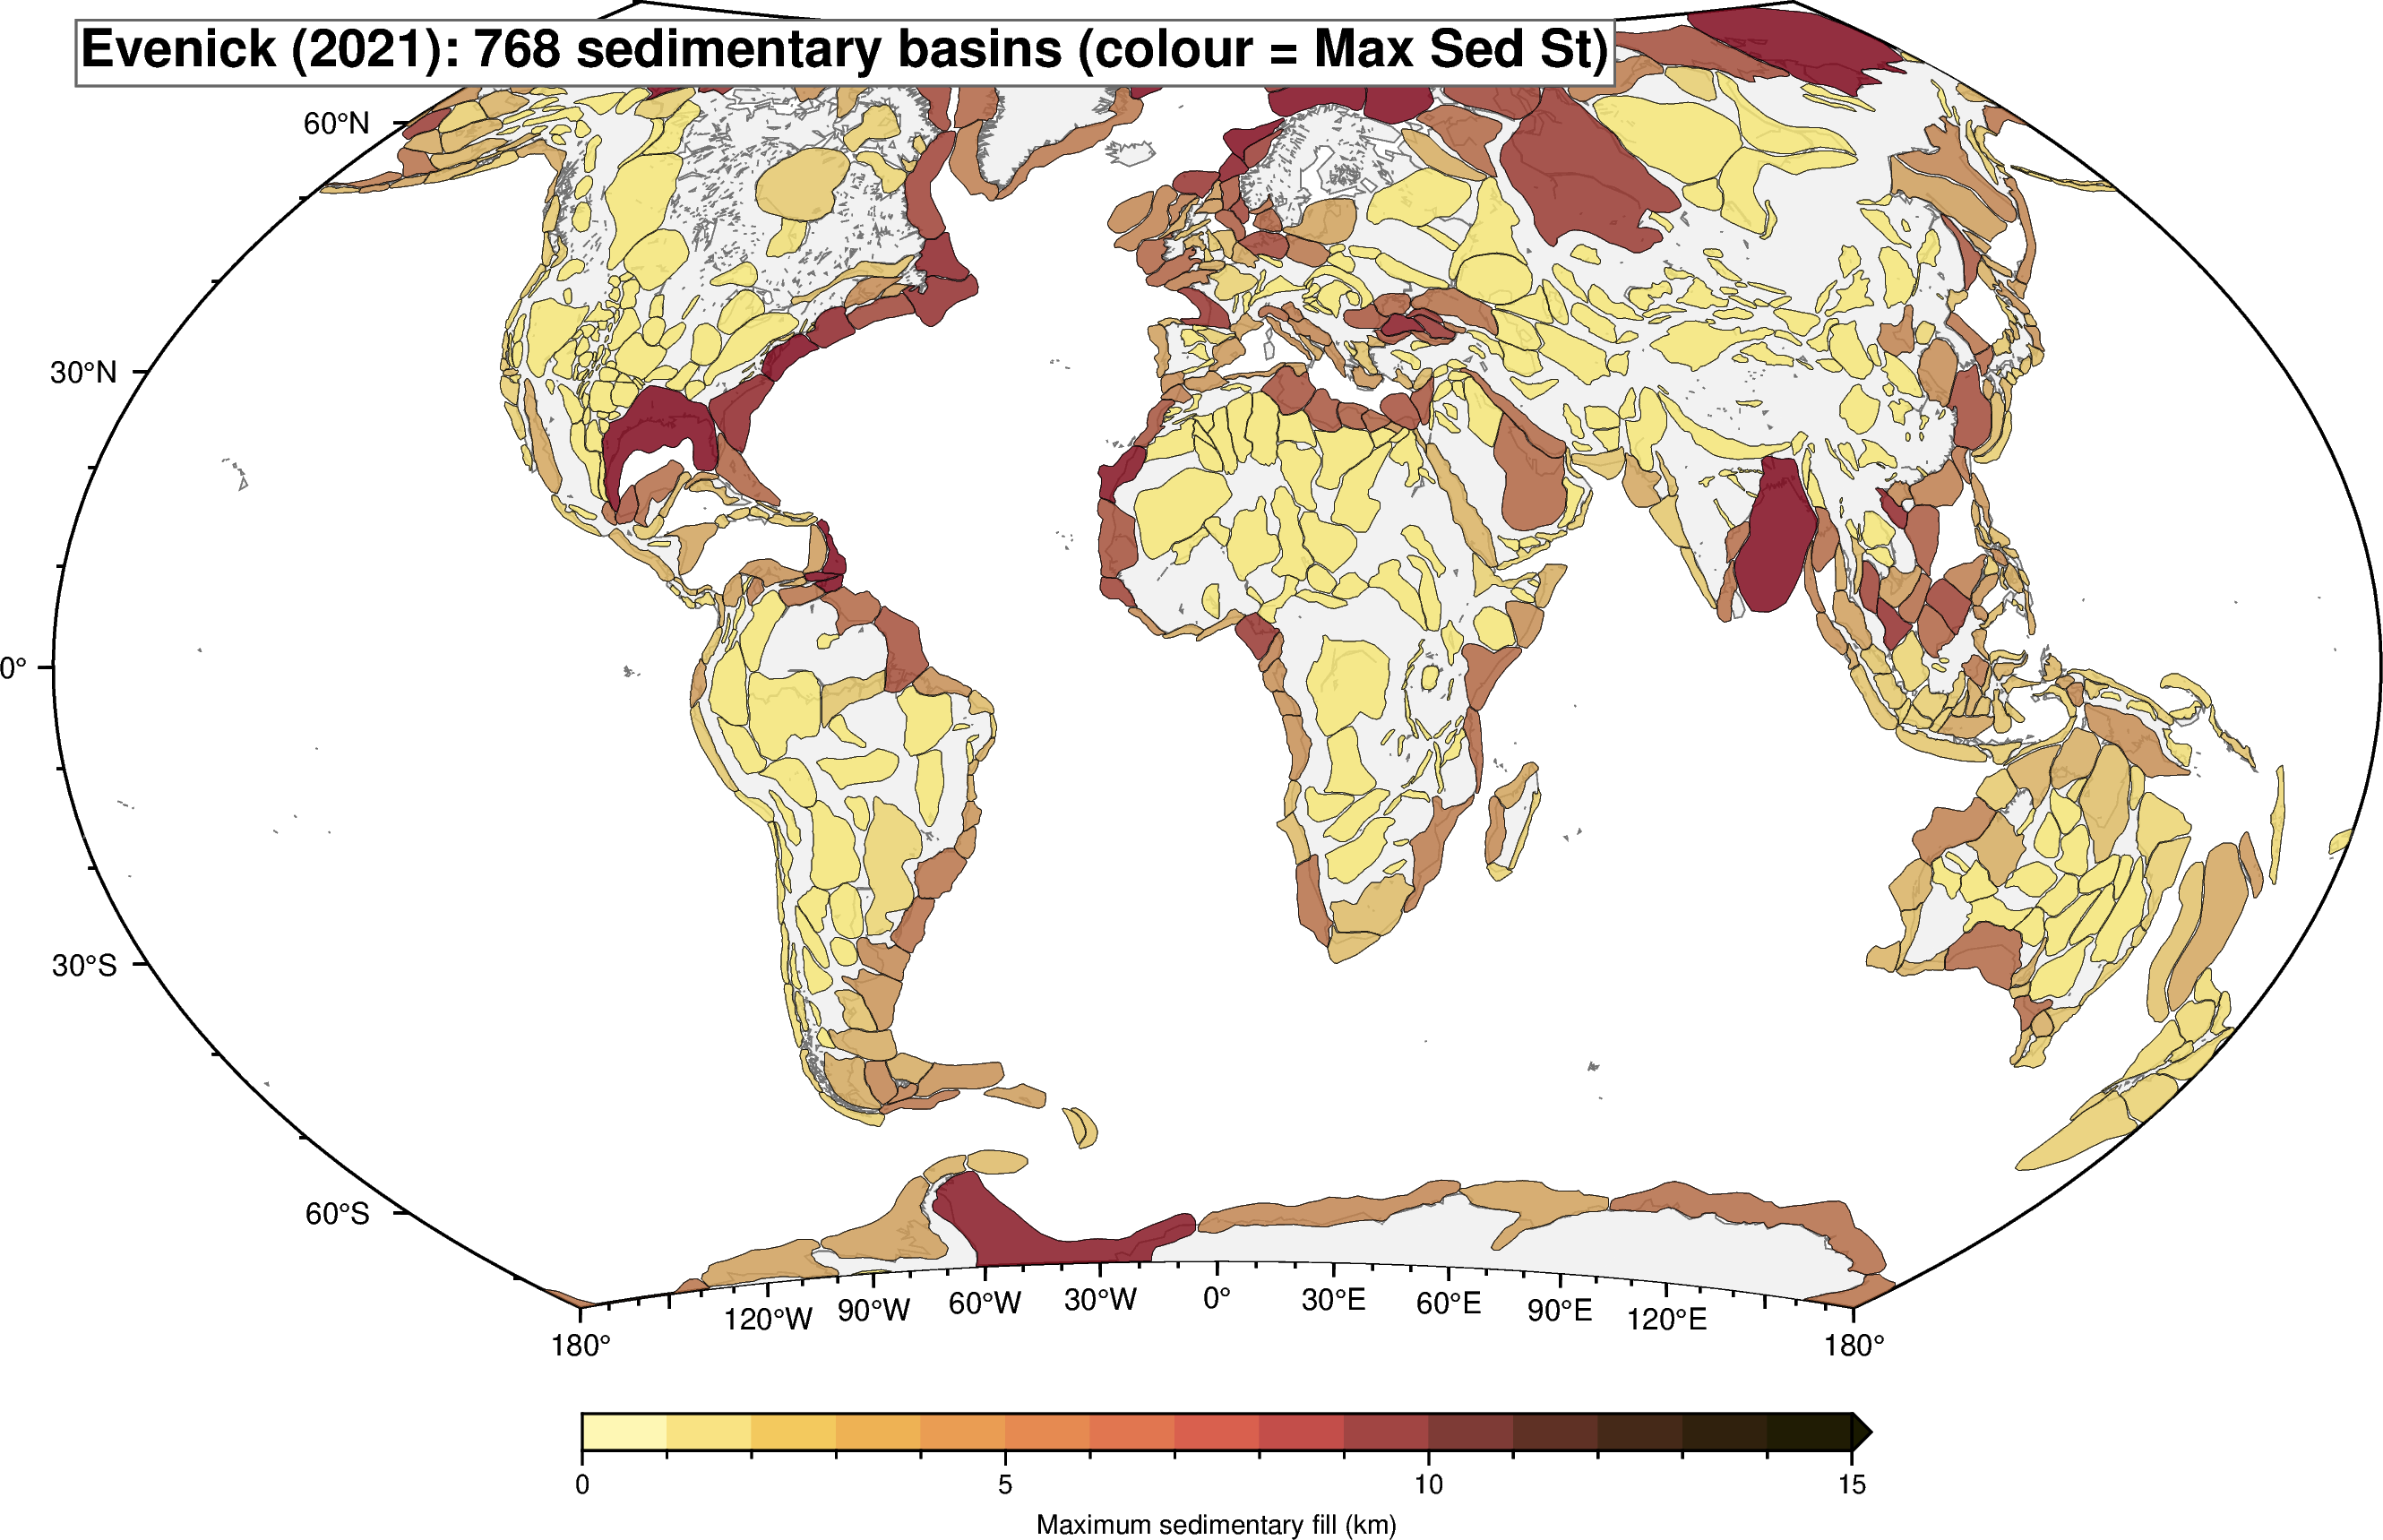

In [4]:
# CPT capped at 15 km. A handful of basins (South Caspian, East Barents,
# Beaufort-Mackenzie, ...) exceed 15 km and saturate at the top-end colour;
# the +ef overflow arrow on the colourbar flags that values continue beyond it.
_FILL_CAP_KM = 15.0

import tempfile
_fd, basin_cpt = tempfile.mkstemp(suffix=".cpt", prefix="T53_basin_fill_")
os.close(_fd)
pygmt.makecpt(cmap="lajolla", series=[0, _FILL_CAP_KM, 1],
              reverse=True, output=basin_cpt)

# lajolla ramp endpoints, sampled from GMT's lajolla palette. Reversed so
# thin sediment = pale, thick sediment = dark orange/brown.
def _lajolla_rgb_for(fill_km):
    """Return an (r, g, b) triplet interpolating the same colours the CPT
    uses. Values above the cap saturate at the top-end colour so the polygon
    fill is consistent with the +ef overflow arrow on the colourbar."""
    _t = min(max(fill_km, 0.0) / _FILL_CAP_KM, 1.0)
    r = int(245 + (128 - 245) * _t)
    g = int(230 + (10  - 230) * _t)
    b = int(120 + (30  - 120) * _t)
    return (r, g, b)

fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
fig.coast(land="gray95", shorelines="0.3p,gray45")

_n_saturated = 0
_n_unreported = 0
for _, row in basins.iterrows():
    fill_km = row["Max Sed St"]
    if not np.isfinite(fill_km):
        fill_km = 0.0
        _n_unreported += 1
    if fill_km > _FILL_CAP_KM: _n_saturated += 1
    geom = row.geometry
    if geom is None or geom.is_empty: continue
    parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    r, g, b = _lajolla_rgb_for(fill_km)
    for part in parts:
        x, y = part.exterior.xy
        fig.plot(x=list(x), y=list(y), fill=f"{r}/{g}/{b}",
                 pen="0.15p,black", close=True, transparency=15)
print(f"  {_n_saturated} basins exceed the {_FILL_CAP_KM:.0f} km cap and "
      f"saturate at the top-end colour (see +ef overflow arrow on colourbar)")
print(f"  {_n_unreported} basins have no reported Max Sed St and are drawn as 0 km (pale)")

# Colorbar with +ef right-hand overflow arrow (values continue > 15 km)
fig.colorbar(cmap=basin_cpt,
             position="JBC+w12c/0.35c+h+o0/1c+ef",
             frame=["a5f1", "x+lMaximum sedimentary fill (km)"])
fig.text(text=f"Evenick (2021): {len(basins)} sedimentary basins (colour = Max Sed St)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


## 3. Panel B — Bird & Mooney (2026) sediment thickness raster + basin outlines


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


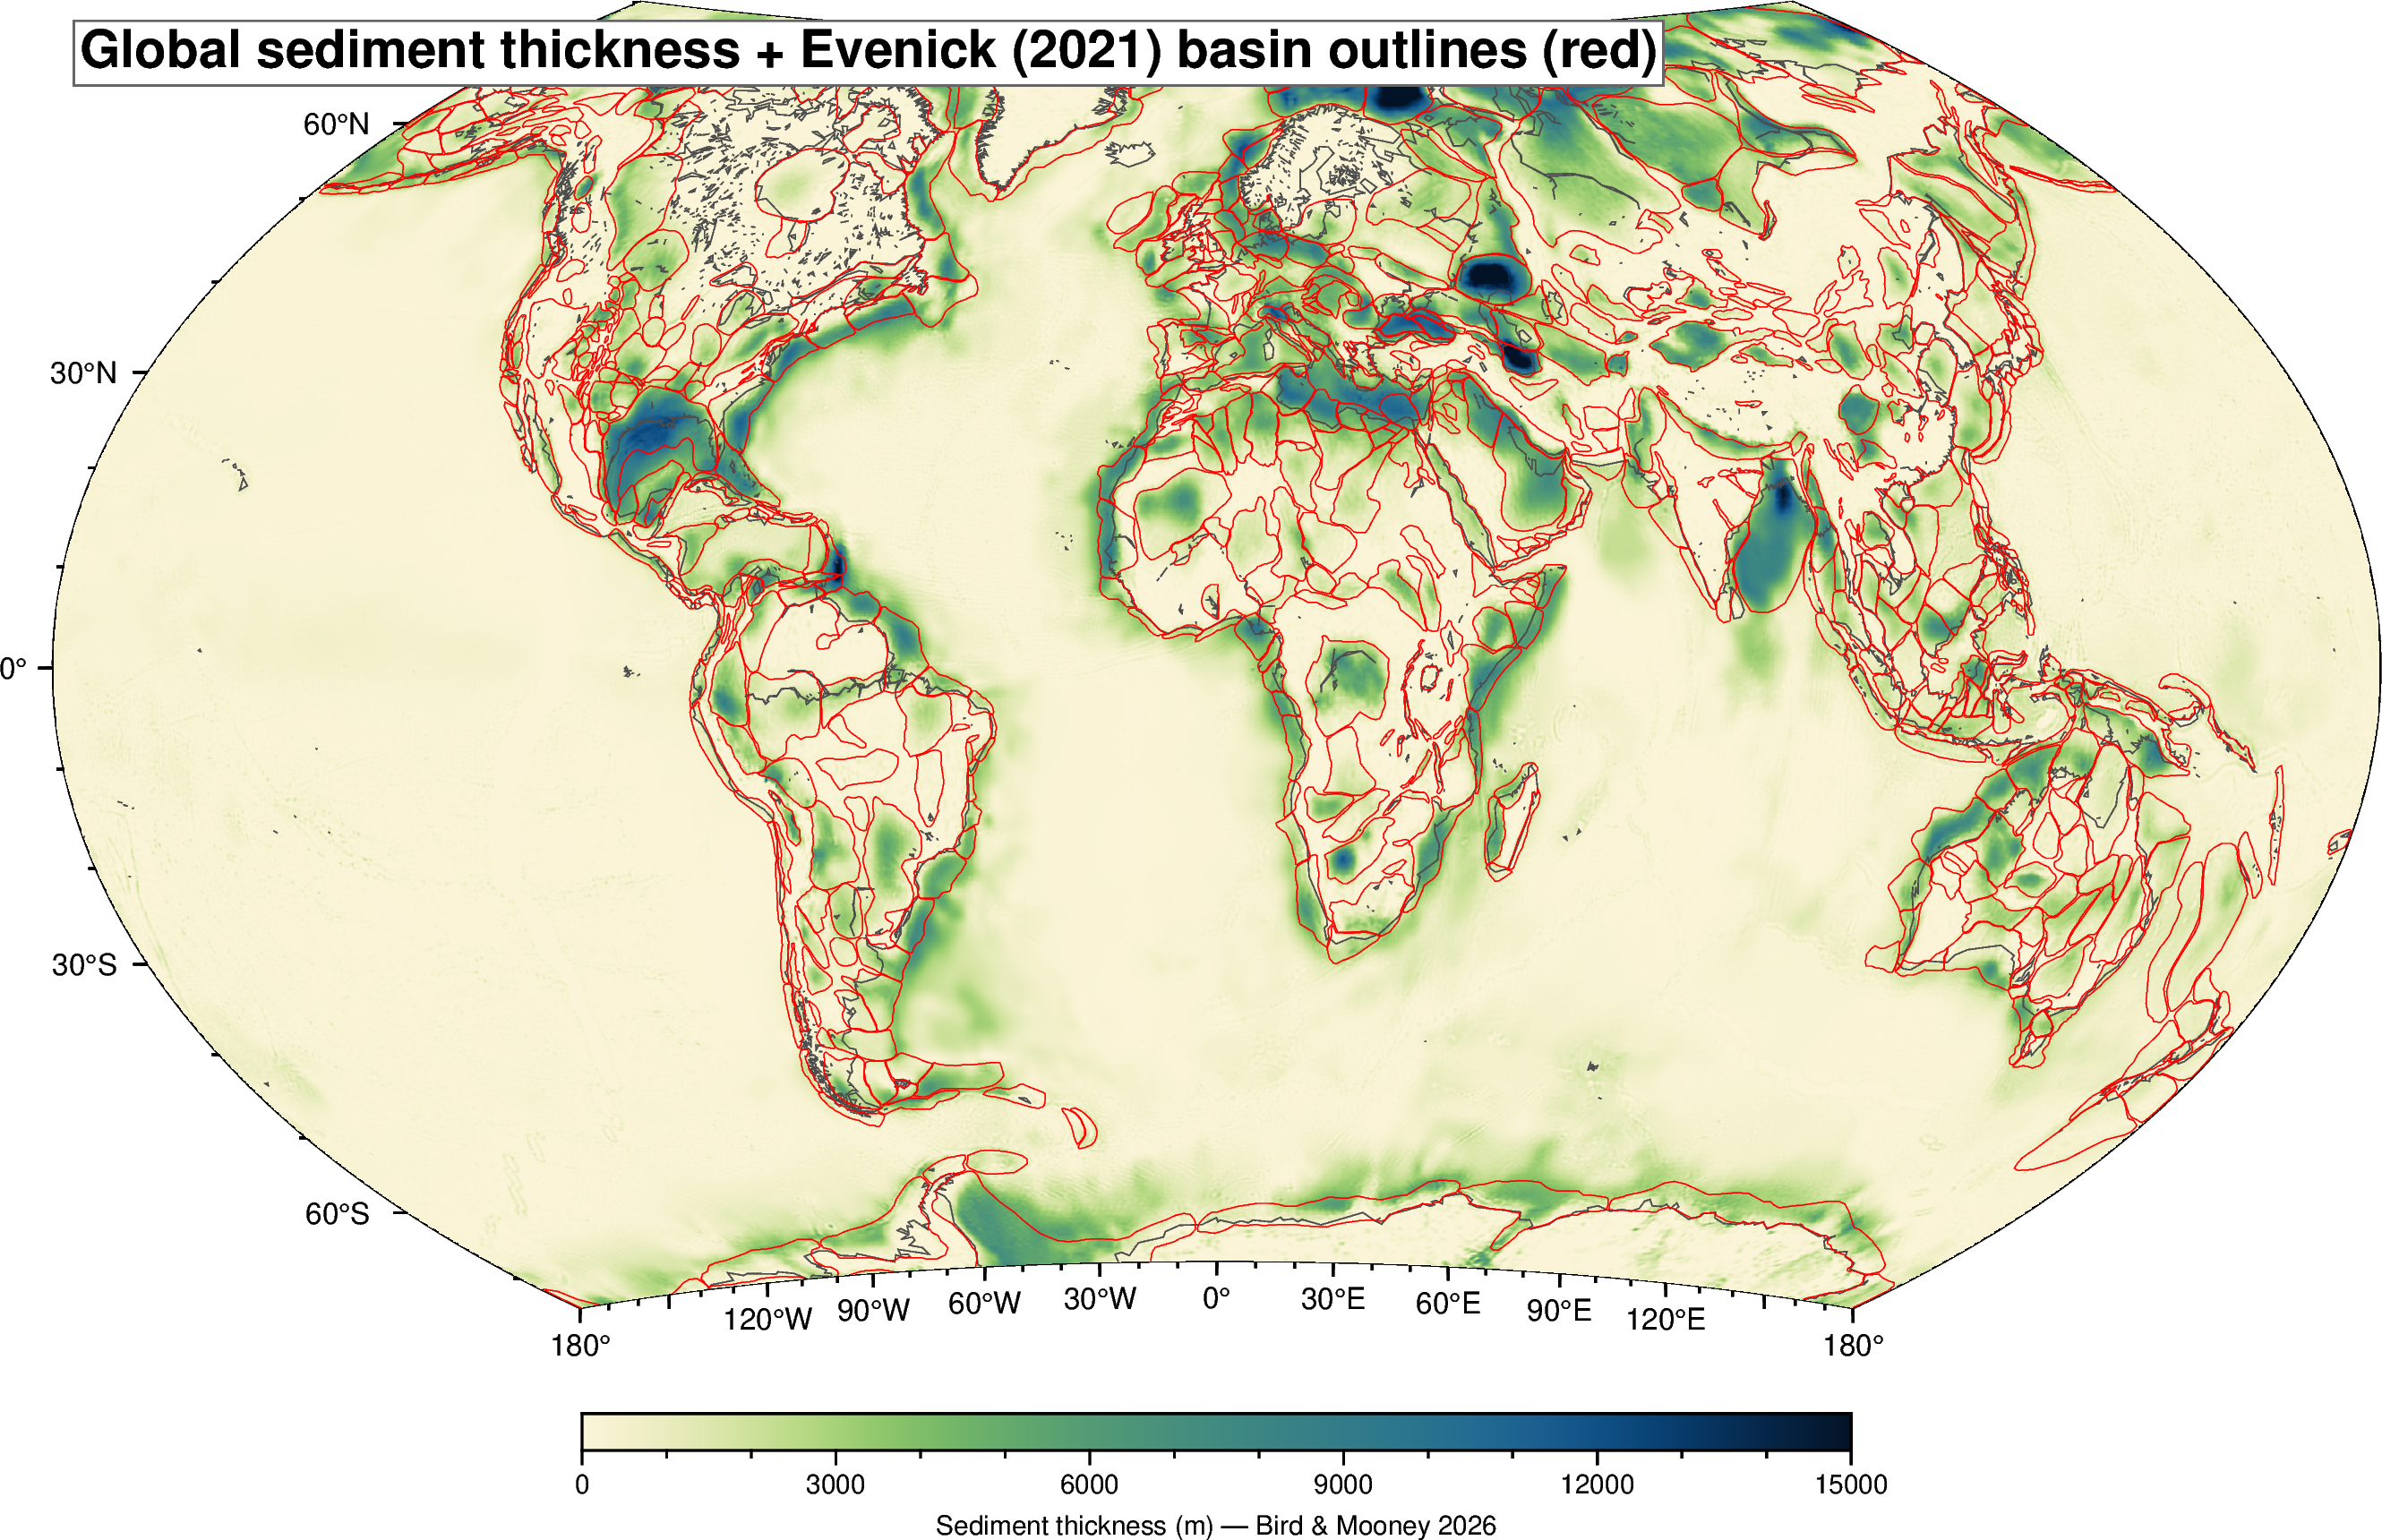

In [5]:
fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
# GMT expects (y, x) dim order for grdimage — Bird & Mooney is already (lat, lon)
pygmt.makecpt(cmap="navia", series=[0, 15000, 250], reverse=True, continuous=True)
fig.grdimage(grid=sed_da, cmap=True, nan_transparent=True)
fig.coast(land=None, shorelines="0.3p,gray30")

# Overlay basin outlines
for _, row in basins.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty: continue
    parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    for part in parts:
        x, y = part.exterior.xy
        fig.plot(x=list(x), y=list(y), pen="0.25p,red", close=True)

fig.colorbar(frame=["a3000f1000", "x+lSediment thickness (m) — Bird & Mooney 2026"],
             position="JBC+w12c/0.35c+h+o0/1c")
fig.text(text="Global sediment thickness + Evenick (2021) basin outlines (red)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


## 4. Panel C — Afonso et al. (2019) crustal thickness raster + basin outlines


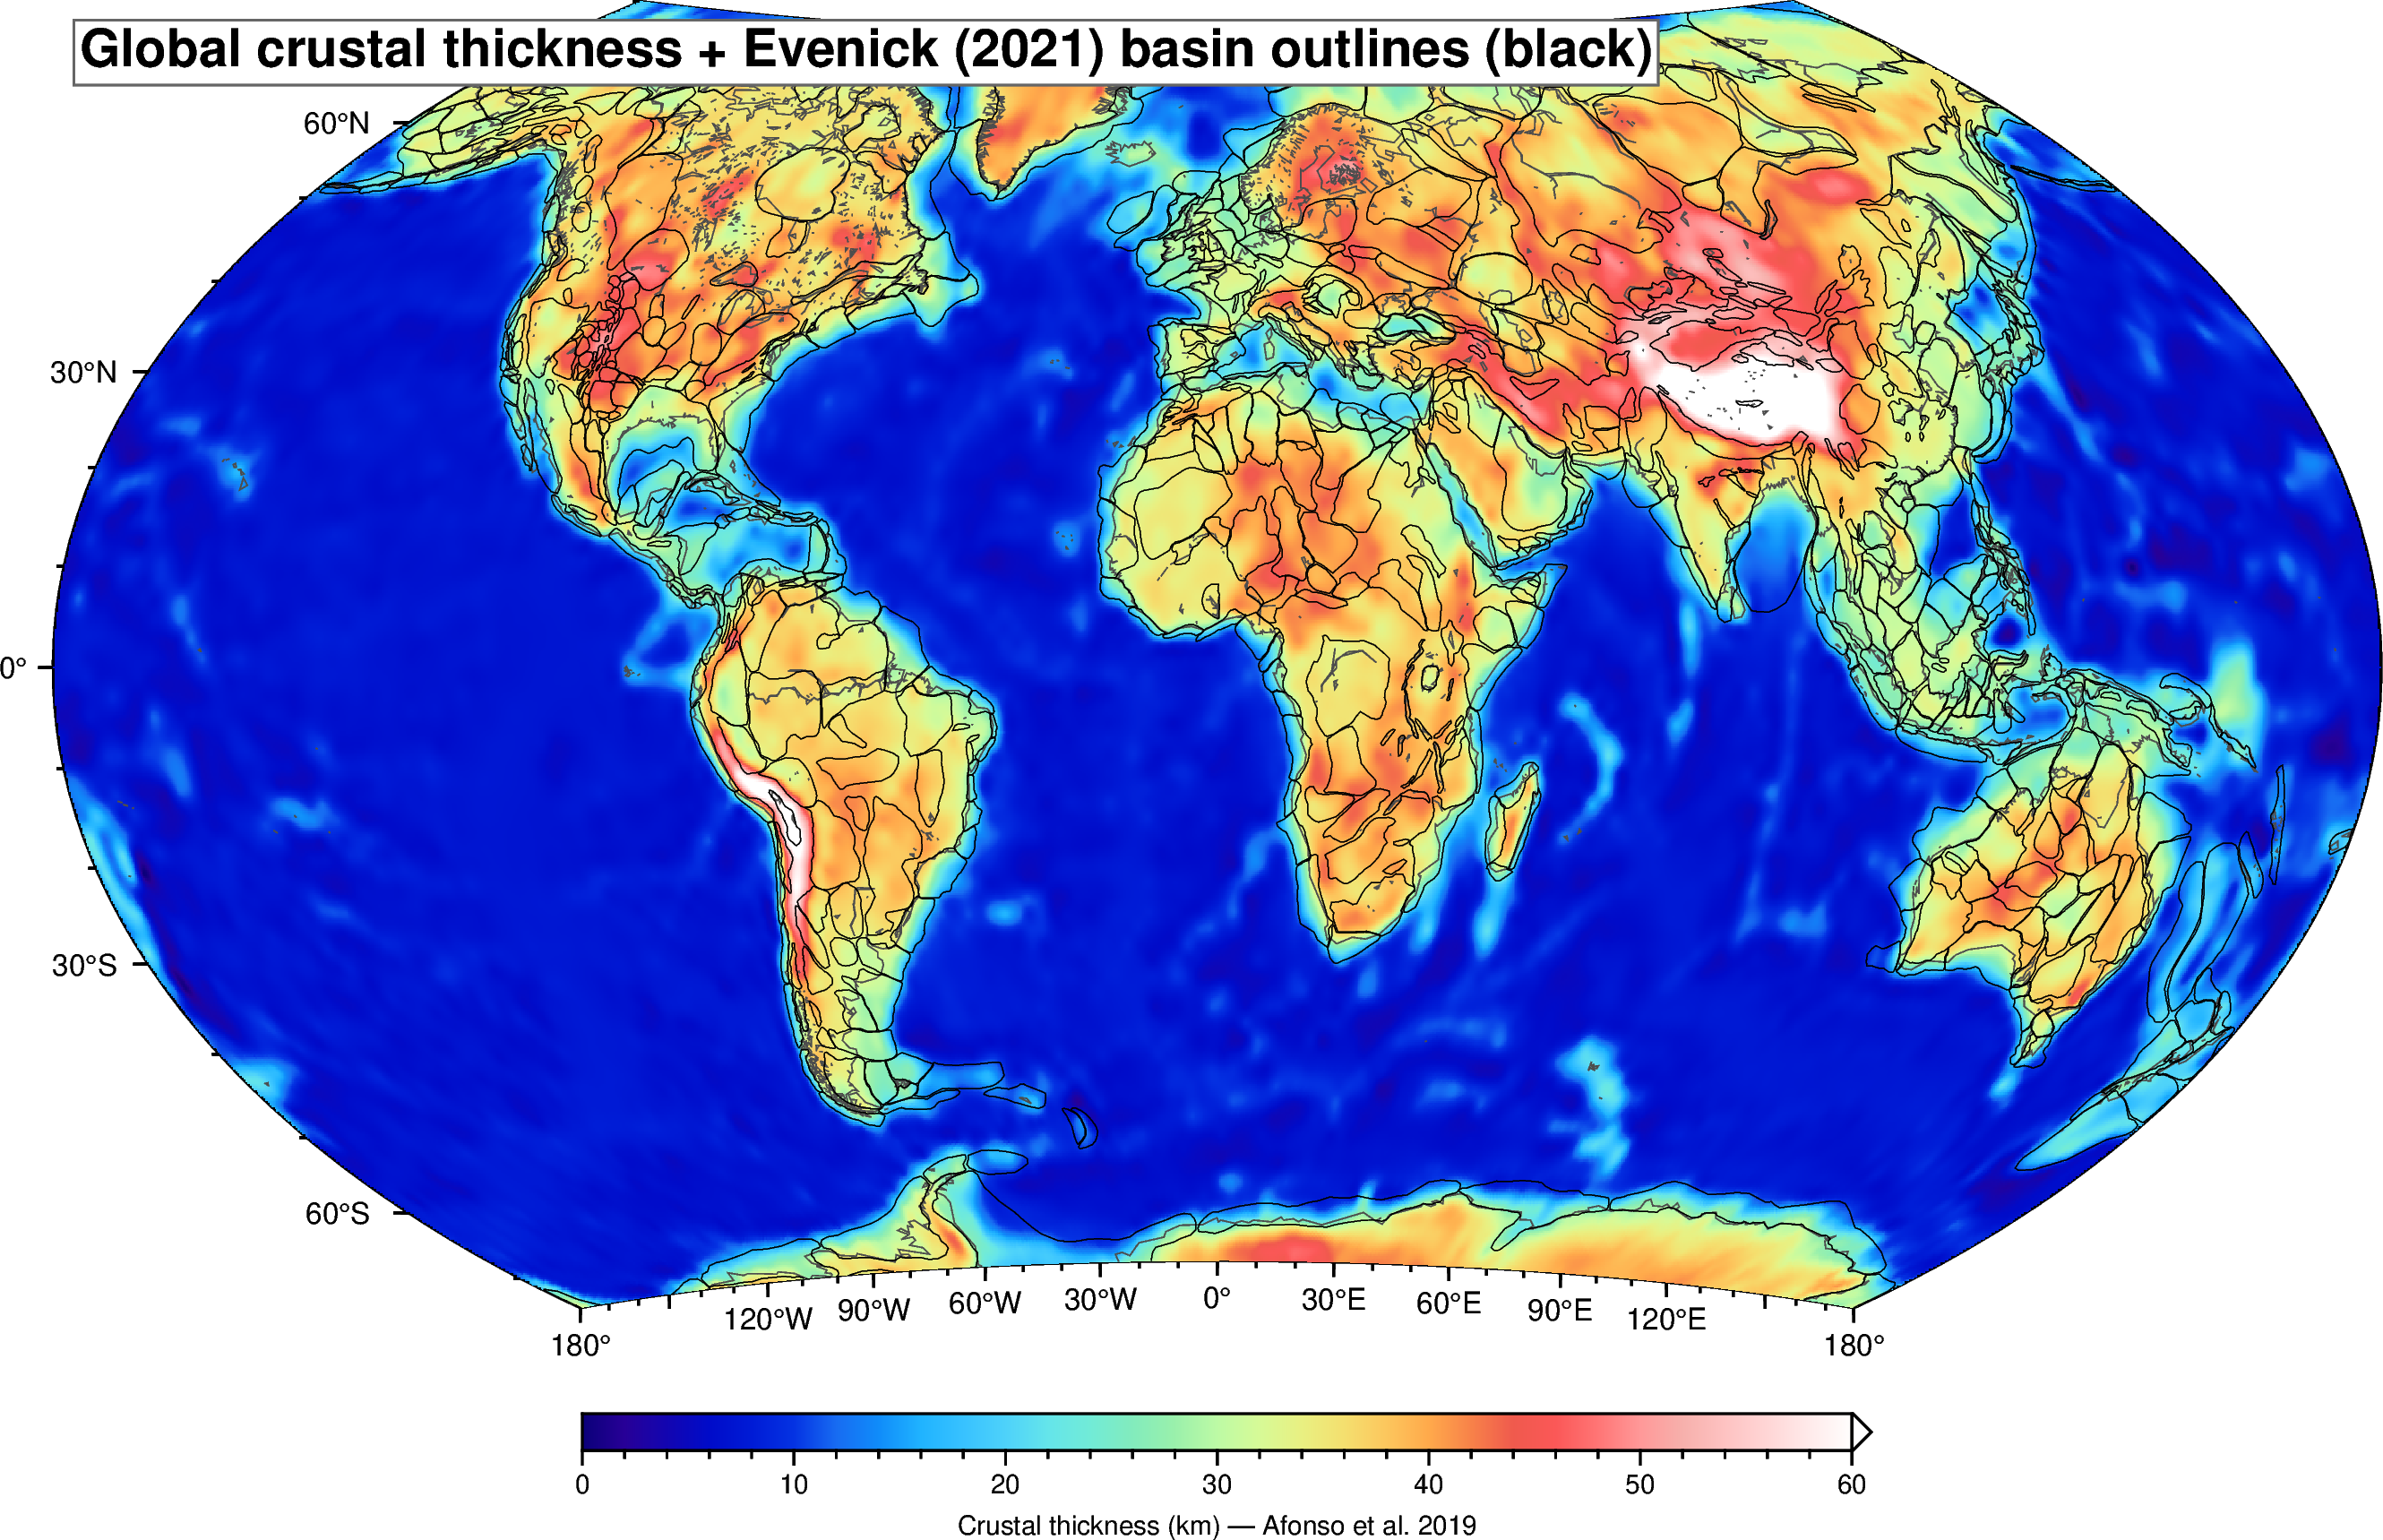

In [6]:
fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
# CPT capped at 60 km with +ef overflow arrow — a small number of cells
# (thick Andean / Tibetan / Himalayan roots) exceed 60 km and saturate at
# the top-end colour; the arrow flags that data continue beyond the cap.
pygmt.makecpt(cmap="haxby", series=[0, 60, 2], continuous=True)
fig.grdimage(grid=crust_da, cmap=True, nan_transparent=True)
fig.coast(land=None, shorelines="0.3p,gray30")

# Overlay basin outlines
for _, row in basins.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty: continue
    parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    for part in parts:
        x, y = part.exterior.xy
        fig.plot(x=list(x), y=list(y), pen="0.25p,black", close=True)

fig.colorbar(frame=["a10f2", "x+lCrustal thickness (km) — Afonso et al. 2019"],
             position="JBC+w12c/0.35c+h+o0/1c+ef")
fig.text(text="Global crustal thickness + Evenick (2021) basin outlines (black)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


## 5. Per-basin zonal means — sample both grids inside every basin polygon, cross-validated

For each of the 768 basins we compute the mean sediment thickness (Bird & Mooney) and mean crustal thickness (Afonso) inside the polygon. The ratio sed/(crust × 1000) is a first-order proxy for extensional stretching. Evenick (2021) also reports its own per-basin mean sediment thickness (`"Mean Sed S"`, from Straume et al. 2019) — we cross-validate our independently-sampled Bird & Mooney (2026) zonal mean against it as a sanity check on the sampling method.

In [7]:
from shapely import contains_xy

def _zonal_mean(da: xr.DataArray, geom) -> float:
    """Mean value of the DataArray inside the shapely polygon."""
    if geom is None or geom.is_empty: return np.nan
    minx, miny, maxx, maxy = geom.bounds
    sub = da.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))
    if sub.size == 0: return np.nan
    LON, LAT = np.meshgrid(sub.lon.values, sub.lat.values)
    mask = contains_xy(geom, LON, LAT)
    vals = sub.values[mask]
    vals = vals[np.isfinite(vals)]
    return float(vals.mean()) if vals.size else np.nan

sed_mean, crust_mean = [], []
for i, row in basins.iterrows():
    sed_mean.append(_zonal_mean(sed_da, row.geometry))
    crust_mean.append(_zonal_mean(crust_da, row.geometry))
    if (i + 1) % 200 == 0:
        print(f"  processed {i+1} of {len(basins)} basins")

basins["sed_thk_mean_m"]   = sed_mean
basins["crust_thk_mean_km"] = crust_mean
# Simple stretching-factor proxy: sediment thickness as a fraction of crustal thickness.
# Bigger = more sediment relative to (thinned) crust.
basins["sed_over_crust"] = (basins["sed_thk_mean_m"] / 1000) / basins["crust_thk_mean_km"]

print(f"\n  sampled sediment thickness — mean {basins['sed_thk_mean_m'].mean():.0f} m, "
      f"max {basins['sed_thk_mean_m'].max():.0f} m")
print(f"  sampled crustal thickness — mean {basins['crust_thk_mean_km'].mean():.1f} km, "
      f"min {basins['crust_thk_mean_km'].min():.1f} km")

# ---- Cross-validation against Evenick's own reported "Mean Sed S" (km) ----
# Independent source (Straume et al. 2019) vs. our own Bird & Mooney (2026)
# zonal-mean sampling — agreement here is a sanity check on the sampling
# method, not a formal accuracy claim (the two grids are different products).
_cmp = basins.dropna(subset=["Mean Sed S", "sed_thk_mean_m"]).copy()
_cmp["our_sed_km"] = _cmp["sed_thk_mean_m"] / 1000.0
_corr = _cmp["our_sed_km"].corr(_cmp["Mean Sed S"])
_mad  = (_cmp["our_sed_km"] - _cmp["Mean Sed S"]).abs().mean()
print(f"\n  cross-validation vs Evenick's own \"Mean Sed S\" (n={len(_cmp)}): "
      f"corr={_corr:.2f}, mean abs diff={_mad:.2f} km")

# Show the top 15 thickest-sediment basins
print("\n  top 15 basins by mean sediment thickness:")
print(basins.nlargest(15, "sed_thk_mean_m")
            [["Basin Name", "Region", "Poly Area",
              "Max Sed St", "sed_thk_mean_m", "crust_thk_mean_km"]]
            .to_string(index=False))


  processed 200 of 768 basins


  processed 400 of 768 basins


  processed 600 of 768 basins



  sampled sediment thickness — mean 2093 m, max 12505 m
  sampled crustal thickness — mean 31.8 km, min 9.6 km

  cross-validation vs Evenick's own "Mean Sed S" (n=427): corr=0.84, mean abs diff=0.79 km

  top 15 basins by mean sediment thickness:
        Basin Name          Region  Poly Area  Max Sed St  sed_thk_mean_m  crust_thk_mean_km
     South Caspian     Middle East     246872         NaN    12504.556641          39.478502
      East Barents            Asia    2155945   17.004550    11859.363281          28.967640
     North Caspian            Asia     857405         NaN    10853.216797          35.019518
Beaufort-Mackenzie   North America     586957   18.064540    10525.395508          23.481796
 Eastern Black Sea            Asia     120609   12.331000    10019.486328          30.468529
 Western Black Sea            Asia     152126   14.095150     9788.220703          25.842585
        Nile Delta          Africa     250736   10.333950     9137.650391          21.918834
       

## 6. Basin counts by region and basin type

  9 regions
                 n_basins  total_area_km2  mean_max_sed_km
Region                                                    
Asia                  244        61728118         4.948104
North America         146        36525054         5.872564
Africa                100        21205616         6.611454
Europe                 72        13756548         6.886016
South America          71        16702926         4.332201
South Pacific          56        15718912         2.726022
Central America        35         3708837         4.980702
Middle East            31         4549881         5.052864
Antarctica             13        29898885         5.457612

  8 basin types
                        n_basins  total_area_km2
Basin Type                                      
Passive Margin               153        90324052
Rift                         130        10674738
Strike-Slip                  111         8722166
Foreland                     108        33084305
Backarc - Marginal Sea      

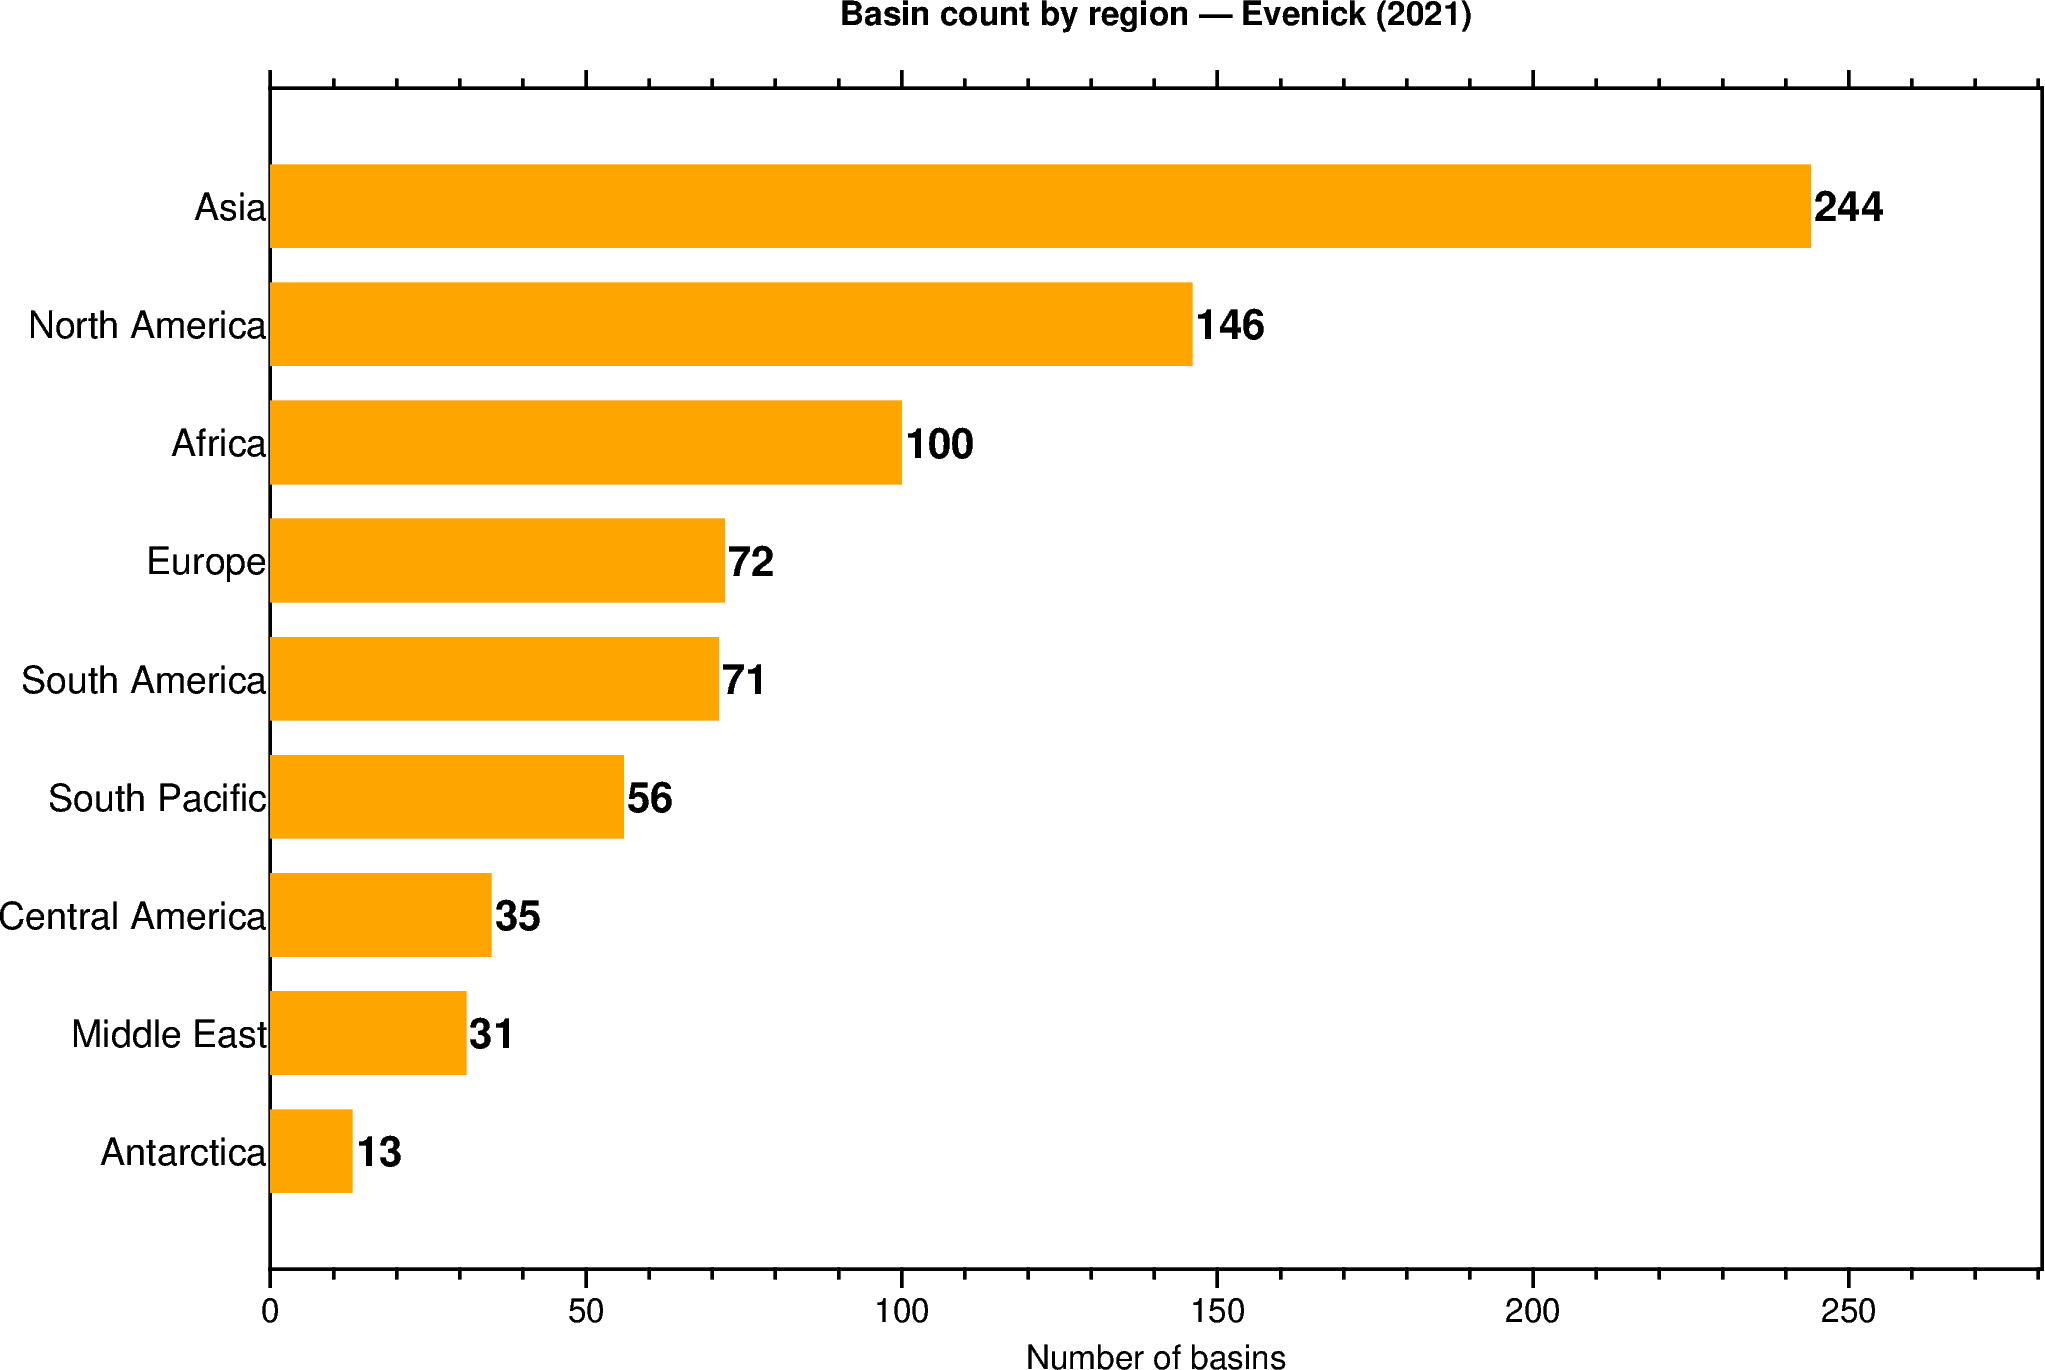

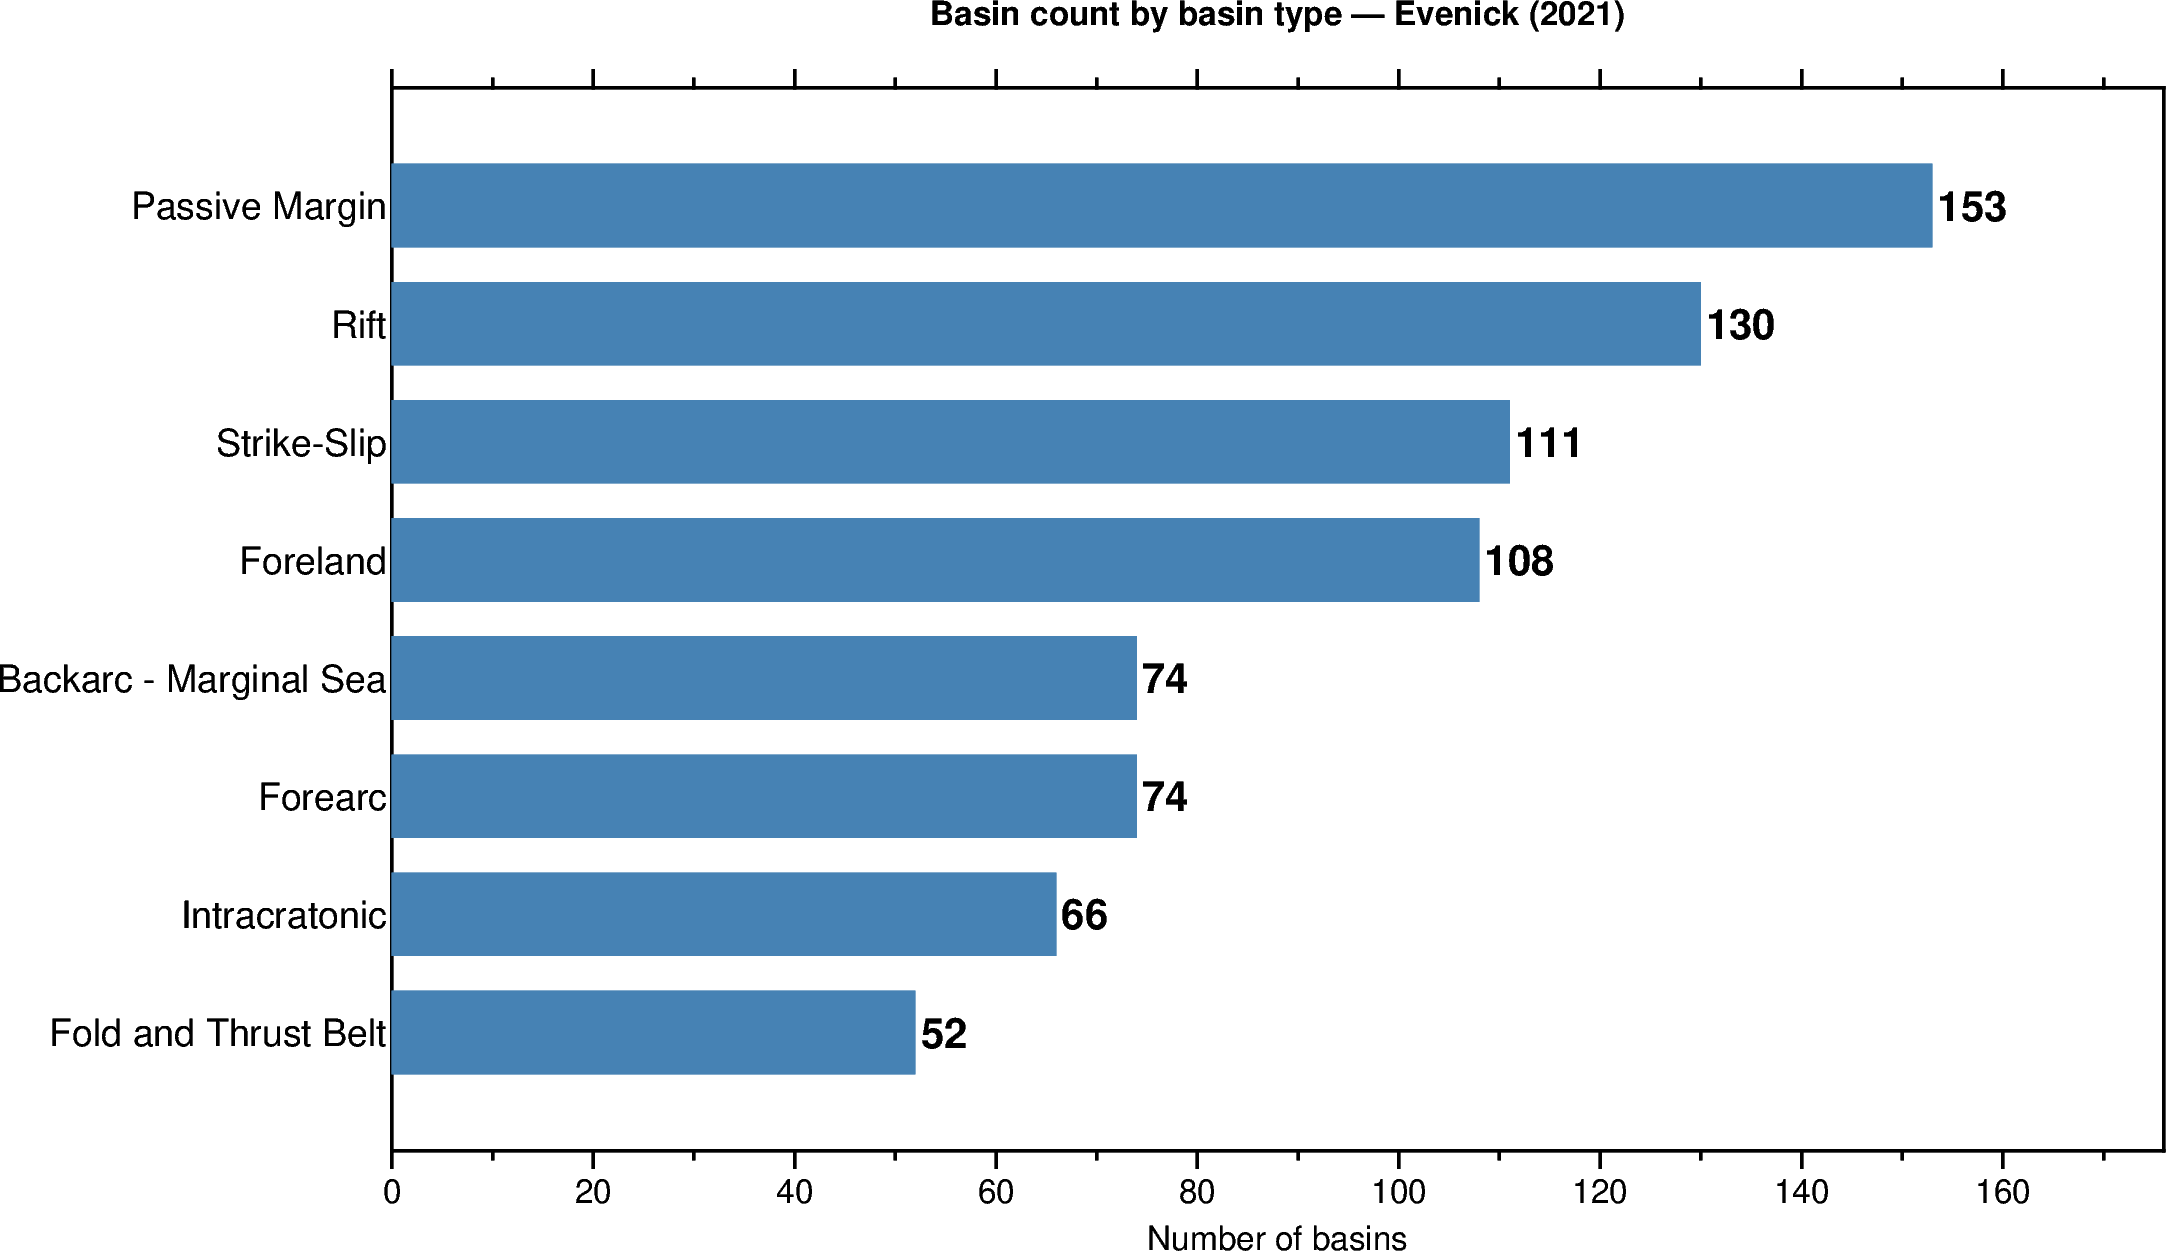

In [8]:
grp = (basins.groupby("Region")
              .agg(n_basins=("Basin UBI", "size"),
                   total_area_km2=("Poly Area", "sum"),
                   mean_max_sed_km=("Max Sed St", "mean"))
              .sort_values("n_basins", ascending=False))
print(f"  {len(grp)} regions")
print(grp.to_string())

grp_type = (basins.groupby("Basin Type")
                   .agg(n_basins=("Basin UBI", "size"),
                        total_area_km2=("Poly Area", "sum"))
                   .sort_values("n_basins", ascending=False))
print(f"\n  {len(grp_type)} basin types")
print(grp_type.to_string())

# Horizontal bar chart — basin count by region.
top = grp.reset_index()
y     = np.arange(len(top))[::-1] + 1     # y positions (top row = row 1)
x_max = top["n_basins"].max() * 1.15
fig = pygmt.Figure()
fig.basemap(region=[0, x_max, 0, len(top) + 1],
            projection="X15c/10c",
            frame=["wSne+tBasin count by region — Evenick (2021)",
                   "xaf+lNumber of basins"])
for xi, yi, name in zip(top["n_basins"], y, top["Region"]):
    fig.plot(x=[0, xi], y=[yi, yi], pen="20p,orange")
    fig.text(x=xi + 0.5, y=yi, text=f"{int(xi)}",
             justify="ML", font="10p,Helvetica-Bold,black")
    fig.text(x=-0.5, y=yi, text=name[:30],
             justify="MR", font="9p,Helvetica,black", no_clip=True)
fig.show(width=1000)

# Horizontal bar chart — basin count by basin type.
topt  = grp_type.reset_index()
yt    = np.arange(len(topt))[::-1] + 1
xt_max = topt["n_basins"].max() * 1.15
fig2 = pygmt.Figure()
fig2.basemap(region=[0, xt_max, 0, len(topt) + 1],
             projection="X15c/9c",
             frame=["wSne+tBasin count by basin type — Evenick (2021)",
                    "xaf+lNumber of basins"])
for xi, yi, name in zip(topt["n_basins"], yt, topt["Basin Type"]):
    fig2.plot(x=[0, xi], y=[yi, yi], pen="20p,steelblue")
    fig2.text(x=xi + 0.5, y=yi, text=f"{int(xi)}",
              justify="ML", font="10p,Helvetica-Bold,black")
    fig2.text(x=-0.5, y=yi, text=name[:30],
              justify="MR", font="9p,Helvetica,black", no_clip=True)
fig2.show(width=1000)


## 7. Evaporite (salt) basins — joining Evenick's supplementary spreadsheet

The main shapefile's `"Salt"` column already flags evaporite presence/style (`Bedded`, `Mobile`, `Unknown`, `None`) for every basin. Evenick (2021)'s supplementary spreadsheet (`mmc1`, "Evaporite list by basin") goes further: one row per **evaporite occurrence**, so a basin with salt in several stratigraphic intervals (e.g. Permian *and* Jurassic) gets multiple rows. We join it back onto the basin table via the shared `"Basin UBI"` key to build a per-basin evaporite-phase count and a global salt-period histogram — both bundled verbatim under the same CC BY-NC-ND 4.0 terms as the shapefile (see `data/evenick_2021_basins/README.md`).

  368 evaporite-occurrence rows across 217 basins
  217 of 768 basins have at least one dated evaporite occurrence

  top 10 basins by number of evaporite phases:
     Basin Name        Region  n_evap_phases                                                       salt_periods
        Arabian   Middle East              8 Cambrian, Eocene, Jurassic, Mio-Pliocene, Penn., Perm., Tri., Jur.
   Mesopotamian   Middle East              8  Eocene, Jurassic, Mio-Pliocene, Permian, Protero., Cam., Triassic
         Zagros   Middle East              8     Eocene, Jurassic, Mio-Pliocene, Permian, Proterozoic, Triassic
        Somalia        Africa              6                             Cretaceous, Eocene, Jurassic, Triassic
       Pelagian        Africa              5                   Cretaceous, Eocene, Jurassic, Miocene, Paleocene
       Ghadames        Africa              5              Cretaceous, Eocene, Jurassic, Pennsylvanian, Triassic
      Williston North America              5         

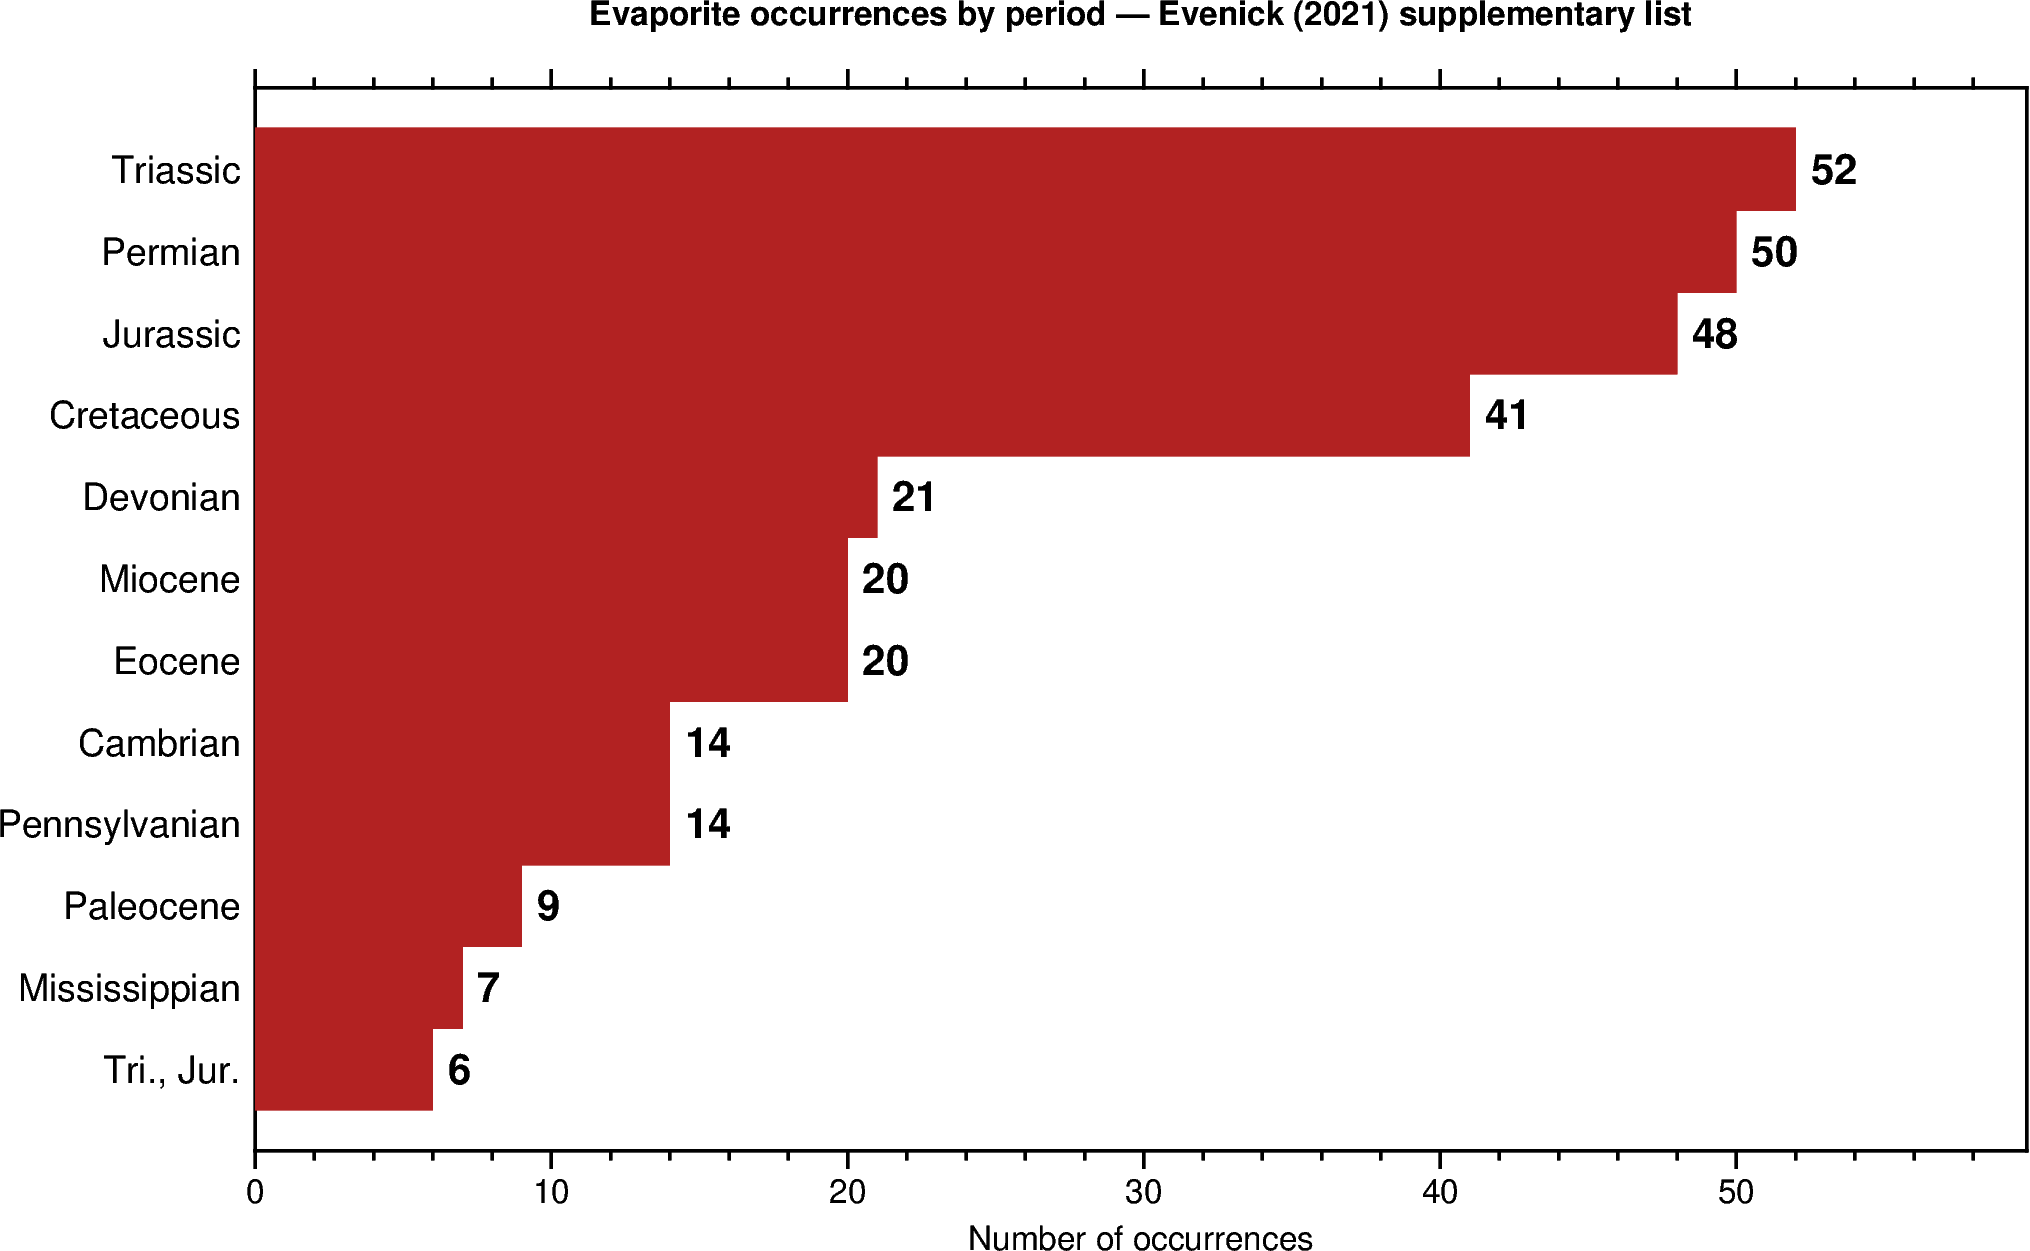

In [9]:
evap = pd.read_excel(EVAPORITE_XLSX)
print(f"  {len(evap)} evaporite-occurrence rows across {evap['Basin UBI'].nunique()} basins")

evap_by_basin = (evap.groupby("Basin UBI")
                      .agg(n_evap_phases=("Evaporite Name", "size"),
                           salt_periods=("Salt Period(s)",
                                         lambda s: ", ".join(sorted(set(s.dropna().astype(str))))))
                      .reset_index())

basins = basins.merge(evap_by_basin, on="Basin UBI", how="left")
basins["n_evap_phases"] = basins["n_evap_phases"].fillna(0).astype(int)
basins["salt_periods"]  = basins["salt_periods"].fillna("")

_n_salt = int((basins["n_evap_phases"] > 0).sum())
print(f"  {_n_salt} of {len(basins)} basins have at least one dated evaporite occurrence")

print("\n  top 10 basins by number of evaporite phases:")
print(basins.nlargest(10, "n_evap_phases")
            [["Basin Name", "Region", "n_evap_phases", "salt_periods"]]
            .to_string(index=False))

# Global salt-period histogram (top 12 periods by occurrence count).
period_counts = evap["Salt Period(s)"].value_counts().head(12)
print("\n  most common salt-bearing periods (occurrence count):")
print(period_counts.to_string())

yp    = np.arange(len(period_counts))[::-1] + 1
xp_max = period_counts.max() * 1.15
fig3 = pygmt.Figure()
fig3.basemap(region=[0, xp_max, 0, len(period_counts) + 1],
             projection="X15c/9c",
             frame=["wSne+tEvaporite occurrences by period — Evenick (2021) supplementary list",
                    "xaf+lNumber of occurrences"])
for xi, yi, name in zip(period_counts.values, yp, period_counts.index):
    fig3.plot(x=[0, xi], y=[yi, yi], pen="20p,firebrick")
    fig3.text(x=xi + 0.5, y=yi, text=f"{int(xi)}",
              justify="ML", font="10p,Helvetica-Bold,black")
    fig3.text(x=-0.5, y=yi, text=str(name)[:24],
              justify="MR", font="9p,Helvetica,black", no_clip=True)
fig3.show(width=1000)


## 8. Paleogeographic reconstruction — basin centroids at PALEO_AGE_MA

Reconstruct every basin's centroid to `PALEO_AGE_MA` via `gplately.Points` on the chosen plate model. Sizes on the map are proportional to log(basin area); colour is `Max Sed St`. The reconstruction reveals where today's basins were during the Pangea breakup epoch (200 Ma), the mid-Cretaceous plate reorganisation (100 Ma), or any other user-chosen slice.

/tmp/ipykernel_21722/2420900170.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

/tmp/ipykernel_21722/2420900170.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



  PlatePartitioner ready with 2391 static polygons
  assigning plate IDs to 768 basin centroids...
  0 of 768 basins on plate 0 (true stationary anchor)


  657 of 768 basin centroids on paleo-continental crust at 200 Ma (dropped 111 offshore/oceanic-crust)


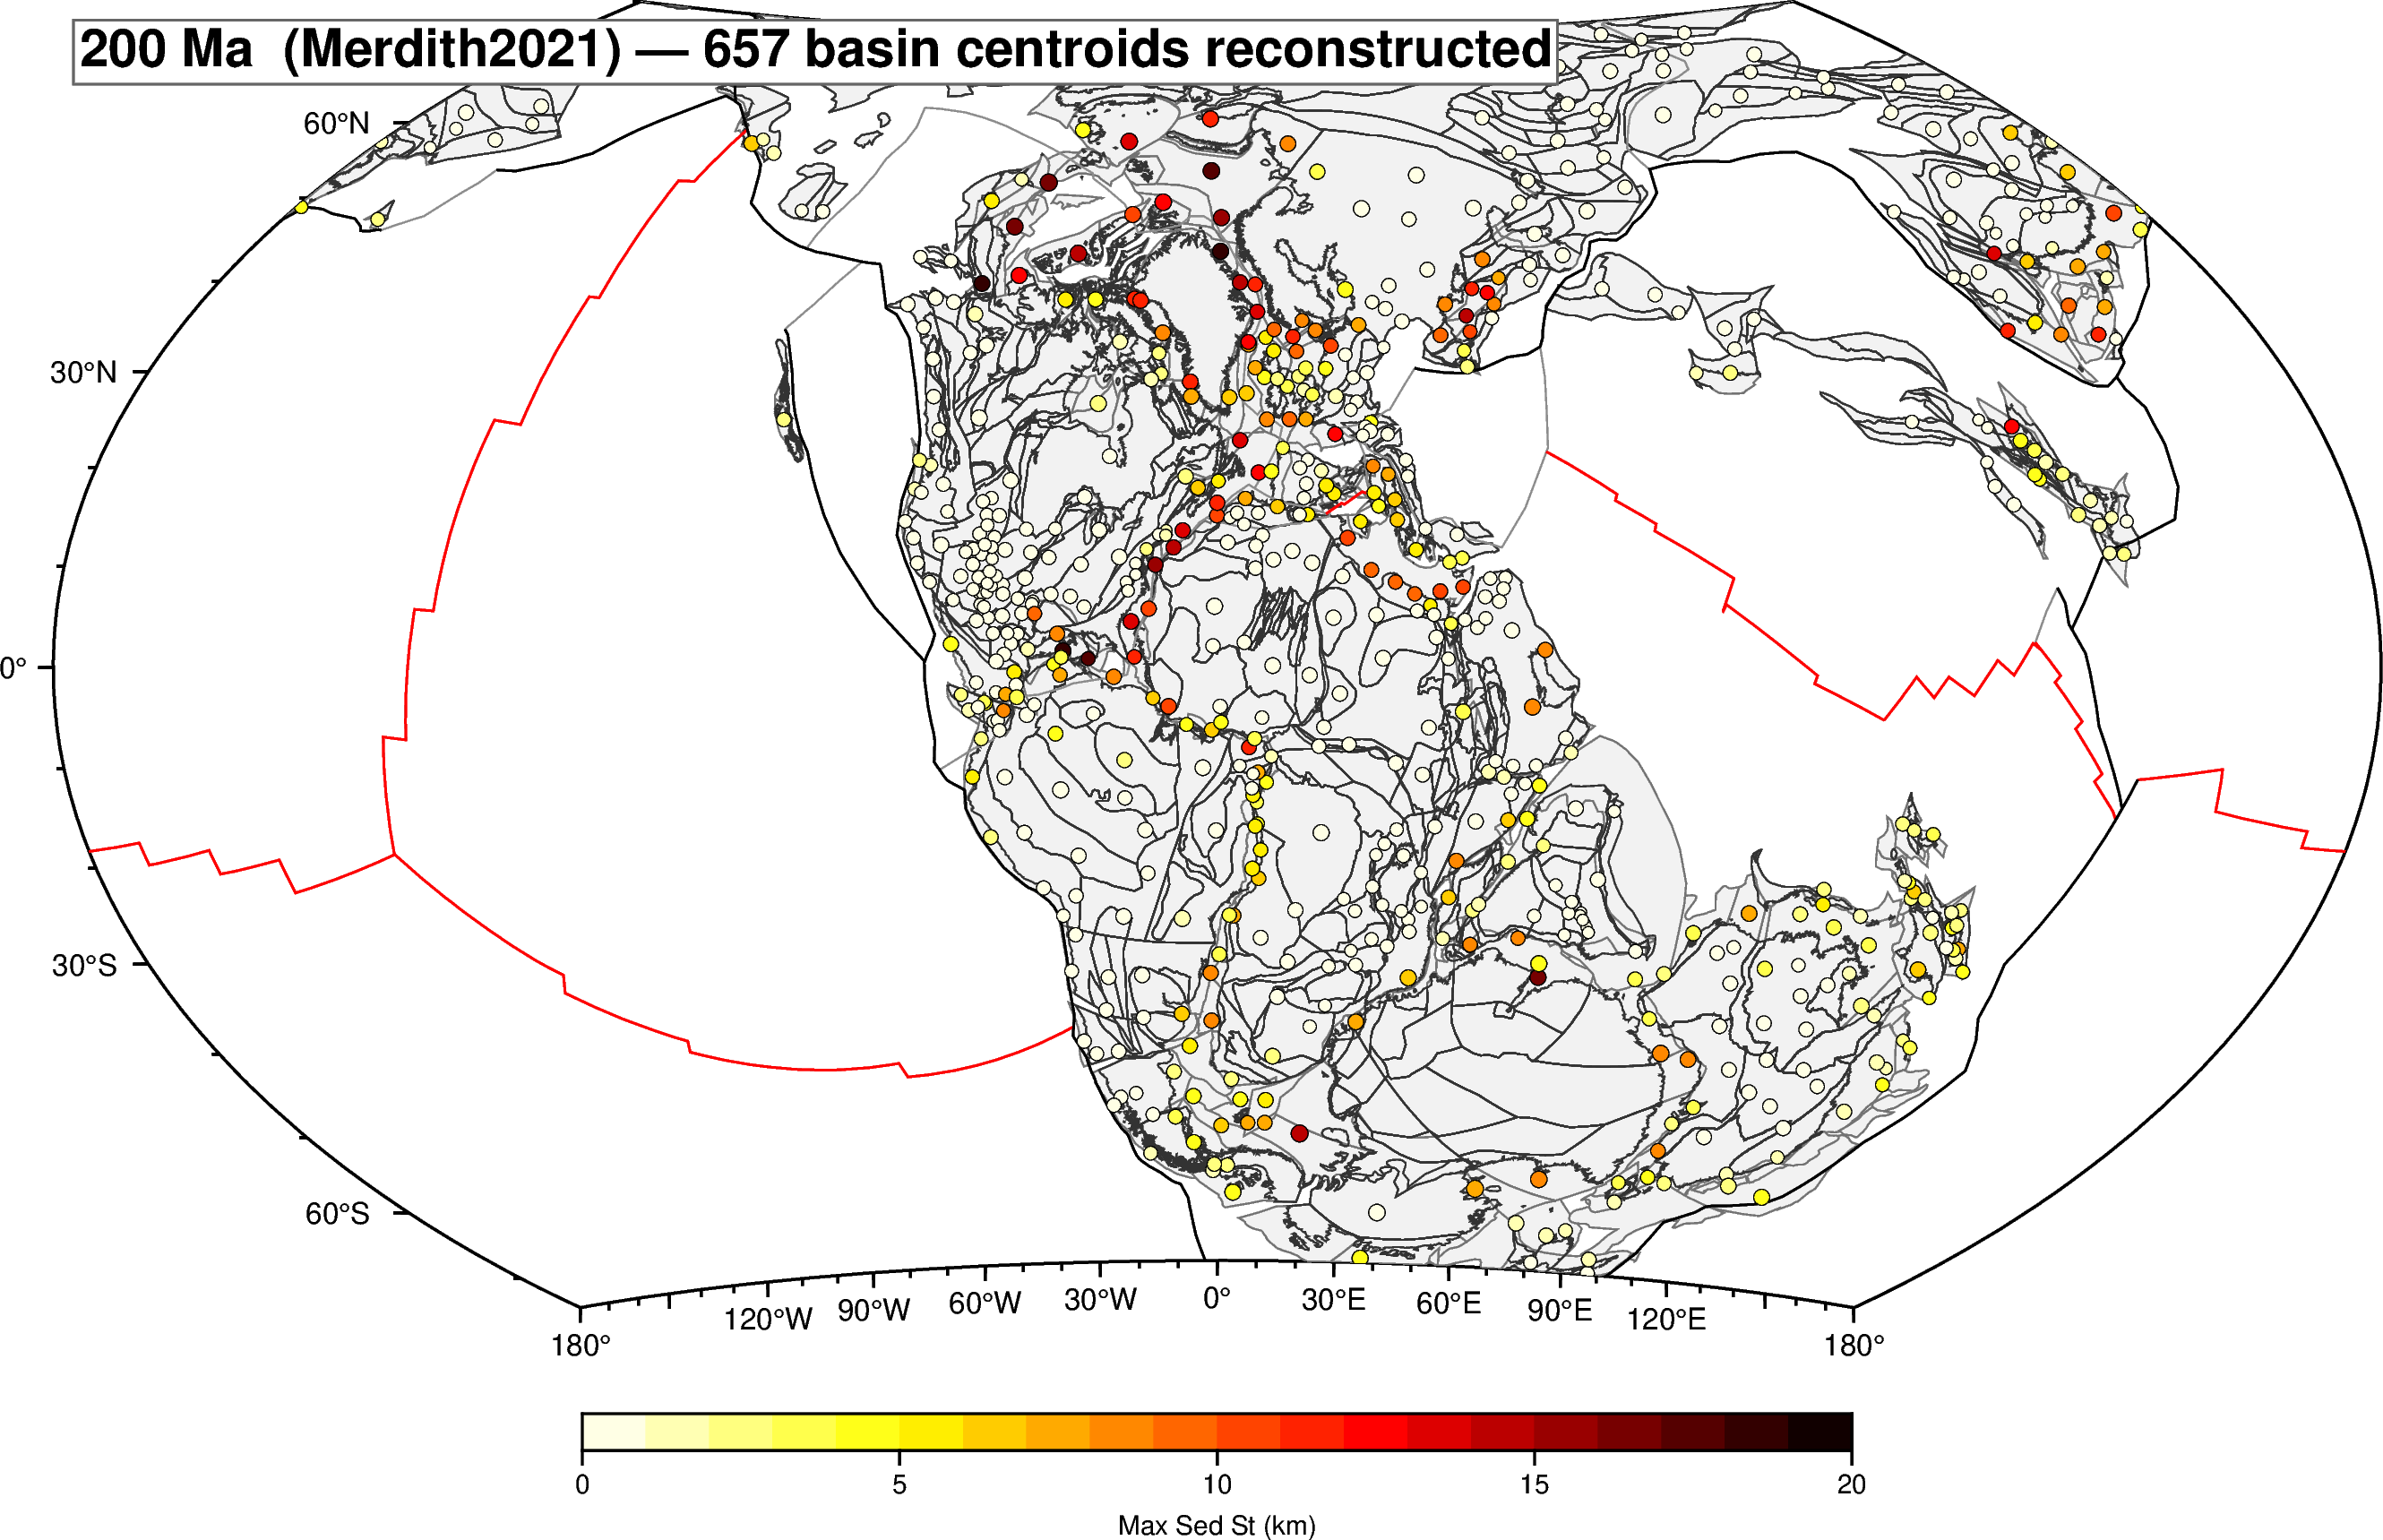

In [10]:
# Compute basin centroids in modern coords
basins["cent_lon"] = basins.geometry.centroid.x
basins["cent_lat"] = basins.geometry.centroid.y

# Set up plate reconstruction + reconstruct centroids
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

# ----------------------------------------------------------------------------
# Plate-ID assignment — canonical GPlates PlatePartitioner over StaticPolygons.
#
# Merdith 2021 has 850 continental-only polygons but 2391 STATIC polygons that
# cover the entire globe (including rifted-margin and oceanic segments). Using
# ContinentalPolygons alone leaves offshore basins with pid=None — they end
# up either unrotated (visually "floating in the ocean at reconstruction age")
# or forced onto a distant continental terrane by a nearest-boundary fallback.
#
# StaticPolygons + PlatePartitioner is the canonical GPlates approach. Every
# point on Earth resolves to a well-defined plate ID under the Merdith
# rotation model, and offshore basins ride the appropriate margin/oceanic
# plate with the correct paleo-position. We reuse this same partitioner in
# §9 below to assign plate IDs to the full basin polygons, not just centroids.
# ----------------------------------------------------------------------------
_static_features = list(pygplates.FeaturesFunctionArgument(
    model.get_static_polygons()).get_features())
_rotation_model  = pygplates.RotationModel(model.get_rotation_model())
_partitioner     = pygplates.PlatePartitioner(_static_features, _rotation_model)
print(f"  PlatePartitioner ready with {len(_static_features)} static polygons")

def assign_plate_ids(lons, lats):
    """Return int array of plate IDs from the Merdith static-polygon
    partition. Any point that fails to partition (extremely rare — poles
    only) gets pid=0 which stays fixed under any rotation."""
    pids = np.zeros(len(lons), dtype=int)
    for i, (lon, lat) in enumerate(zip(lons, lats)):
        pt = pygplates.PointOnSphere(float(lat), float(lon))
        partitioning_plate = _partitioner.partition_point(pt)
        if partitioning_plate is not None:
            pids[i] = int(partitioning_plate.get_feature().get_reconstruction_plate_id())
    return pids

# Assign a real plate ID to every basin centroid.
print(f"  assigning plate IDs to {len(basins)} basin centroids...")
_basin_pids = assign_plate_ids(basins["cent_lon"].to_numpy(),
                                basins["cent_lat"].to_numpy())
basins["plate_id"] = _basin_pids
_n_zero = int((_basin_pids == 0).sum())
print(f"  {_n_zero} of {len(basins)} basins on plate 0 (true stationary anchor)")

gpts  = gplately.Points(recon,
                        basins["cent_lon"].to_numpy(),
                        basins["cent_lat"].to_numpy(),
                        plate_id=_basin_pids,
                        anchor_plate_id=ANCHOR_PLATE_ID)
plons, plats = gpts.reconstruct(float(PALEO_AGE_MA),
                                return_array=True,
                                anchor_plate_id=ANCHOR_PLATE_ID)
basins["paleo_lon"] = plons
basins["paleo_lat"] = plats

recon_ok = basins.dropna(subset=["paleo_lon", "paleo_lat"]).copy()

# ---- Drop backdrop basins that land in the open ocean at this age ----
# (their reconstruction is technically correct — some basins DID form on
# oceanic crust — but showing them as bare dots over blue ocean reads as
# "reconstruction failed". We restrict to basins whose paleo-position sits
# inside a reconstructed continental polygon.)
_cont_recon_at_age = []
_cf = list(pygplates.FeaturesFunctionArgument(
    model.get_layer("ContinentalPolygons")).get_features())
_rr = []
pygplates.reconstruct(_cf, _rotation_model, _rr, float(PALEO_AGE_MA),
                      anchor_plate_id=ANCHOR_PLATE_ID)
for _r in _rr:
    _g = _r.get_reconstructed_geometry()
    if isinstance(_g, pygplates.PolygonOnSphere):
        _cont_recon_at_age.append(_g)
_on_land = np.zeros(len(recon_ok), dtype=bool)
for _i, (_lo, _la) in enumerate(zip(recon_ok["paleo_lon"].to_numpy(),
                                     recon_ok["paleo_lat"].to_numpy())):
    _pt = pygplates.PointOnSphere(float(_la), float(_lo))
    for _pg in _cont_recon_at_age:
        if _pg.is_point_in_polygon(_pt):
            _on_land[_i] = True; break
_n_off = int((~_on_land).sum())
recon_ok = recon_ok.loc[_on_land].copy()
print(f"  {len(recon_ok)} of {len(basins)} basin centroids on paleo-continental "
      f"crust at {PALEO_AGE_MA:.0f} Ma (dropped {_n_off} offshore/oceanic-crust)")

# Set up PlotTopologies for the paleogeographic base
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_layer("Coastlines"),
    continents=model.get_layer("ContinentalPolygons"),
    plot_engine=gplately.PygmtPlotEngine(),
    time=float(PALEO_AGE_MA),
    anchor_plate_id=ANCHOR_PLATE_ID,
)

fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
gplot.plot_continents(fig, fill="gray95", pen="0.4p,gray45")
gplot.plot_coastlines(fig, pen="0.4p,gray20")
try:
    gplot.plot_all_topological_sections(fig, pen="0.4p,gray55")
    gplot.plot_ridges(fig, pen="0.6p,red")
    gplot.plot_trenches(fig, pen="0.6p,black")
except Exception as _e:
    print(f"  topology overlay skipped: {_e}")

# Reconstructed basin centroids — size ∝ log(area), colour ∝ Max Sed St
import tempfile
_fd, cent_cpt = tempfile.mkstemp(suffix=".cpt", prefix="T53_paleo_cent_")
os.close(_fd)
pygmt.makecpt(cmap="hot", series=[0, 20, 1], reverse=True, output=cent_cpt)

sizes = 0.06 + 0.10 * np.log10(np.clip(recon_ok["Poly Area"], 100, 5e6)) / 6.7
xyz = np.column_stack([
    recon_ok["paleo_lon"].to_numpy(),
    recon_ok["paleo_lat"].to_numpy(),
    recon_ok["Max Sed St"].fillna(0).to_numpy(),
    sizes.values,
])
fig.plot(data=xyz, style="cc", cmap=cent_cpt, pen="0.2p,black")
fig.colorbar(cmap=cent_cpt,
             frame=["a5", "x+lMax Sed St (km)"],
             position="JBC+w12c/0.35c+h+o0/1c")

fig.text(text=f"{PALEO_AGE_MA:.0f} Ma  ({MODEL_NAME}) — {len(recon_ok)} basin centroids reconstructed",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


## 9. Export basin polygons as a `pygplates` "Basin" feature collection (`.gpmlz`)

Every basin polygon is converted to a `pygplates.Feature` with GPGIM feature type `gpml:Basin`, named from Evenick's `"Basin Name"` column, with reconstruction plate ID assigned from the same `PlatePartitioner` built over the plate model's static polygons in §8 (reusing `_partitioner` and each basin's centroid-derived `plate_id`). The resulting feature collection is written to `.gpmlz` — this is a **generated, reproducible output** of running this notebook, not a file redistributed with the tutorial suite (see the license note in the introduction). Re-running this cell with a different `MODEL_NAME` regenerates it against a different plate model's plate-ID scheme.

In [11]:
def _shapely_polygon_to_pygplates(poly):
    """Convert a shapely Polygon's exterior ring to a pygplates PolygonOnSphere.
    pygplates uses (latitude, longitude) point order — the OPPOSITE of
    shapely's (lon, lat) — so coordinates must be swapped. Interior rings
    (holes) are dropped, matching the exterior-only outlines used for
    plotting throughout this notebook."""
    lon, lat = poly.exterior.coords.xy
    return pygplates.PolygonOnSphere([(la, lo) for lo, la in zip(lon, lat)])

def _geom_to_pygplates_polygons(geom):
    if geom is None or geom.is_empty:
        return []
    parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    return [_shapely_polygon_to_pygplates(part) for part in parts]

_basin_features = []
_n_skipped = 0
for _, row in basins.iterrows():
    _polys = _geom_to_pygplates_polygons(row.geometry)
    if not _polys:
        _n_skipped += 1
        continue
    _feature = pygplates.Feature(pygplates.FeatureType.create_gpml("Basin"))
    _feature.set_name(str(row["Basin Name"]))
    _feature.set_geometry(_polys if len(_polys) > 1 else _polys[0])
    _feature.set_reconstruction_plate_id(int(row["plate_id"]))
    _basin_features.append(_feature)

BASINS_GPMLZ_OUT.parent.mkdir(parents=True, exist_ok=True)
pygplates.FeatureCollection(_basin_features).write(str(BASINS_GPMLZ_OUT))
print(f"  wrote {len(_basin_features)} Basin features to {BASINS_GPMLZ_OUT} "
      f"({_n_skipped} basins skipped — empty/missing geometry)")

# Round-trip sanity check.
_fc_check = pygplates.FeatureCollection(str(BASINS_GPMLZ_OUT))
_features_back = list(_fc_check)
print(f"  round-trip check: read back {len(_features_back)} features; "
      f"first = \"{_features_back[0].get_name()}\" "
      f"({_features_back[0].get_feature_type()}, plate ID {_features_back[0].get_reconstruction_plate_id()})")


  wrote 768 Basin features to outputs/T53_evenick_basins.gpmlz (0 basins skipped — empty/missing geometry)
  round-trip check: read back 768 features; first = "Aaiun-Tarfaya" (gpml:Basin, plate ID 714)


### How to read the paleogeographic map

Every dot is one modern-day sedimentary basin, reconstructed to its position at PALEO_AGE_MA via Merdith 2021. Symbol size is proportional to log(area) — a huge dot is a continental-scale basin. Colour is `Max Sed St`: pale yellow = shallow-fill basins, dark red = 15+ km fills (rare — some deep passive-margin and intracratonic basins, e.g. South Caspian, East Barents, Beaufort-Mackenzie).

At **200 Ma** (Early Jurassic), the North Atlantic conjugate rift-margin basins cluster along the tight join between eastern North America and NW Africa. The Central Atlantic basins hug the future Central Atlantic Magmatic Province margins. Circum-Tethys basins line the northern margin of Gondwana. This is a first look; deeper analyses via `gplately.Points` on the polygon boundaries (rather than centroids) would reveal how basin shapes evolved through rifting.

Try changing `PALEO_AGE_MA` in the CONFIGURATION cell to explore other epochs — 300 Ma (mid-Permian, Pangea assembly), 100 Ma (mid-Cretaceous), 50 Ma (Palaeocene–Eocene). The rate at which basins cluster / disperse through time is a direct proxy for continental rifting/collision episodes.

## Extend this

- **Reconstruct polygons, not centroids.** For every basin, densify its boundary with `shapely.LineString.interpolate` and reconstruct each vertex individually via `gplately.Points` (or reconstruct the `.gpmlz` feature collection built in §9 directly with `pygplates.reconstruct`). That gives you the FULL basin outline at PALEO_AGE_MA — the paleo-shape reveals rift-to-drift asymmetry, breakup obliquity, and basin fragmentation.
- **Sweep through time.** Loop PALEO_AGE_MA ∈ [0, 10, 20, ...] to animate basin trajectories. Basin dots that migrate together are on the same plate; dots that diverge mark rifting; dots that converge mark collision.
- **Backstrip sediment thickness.** Use the `pyBacktrack` library on the per-basin mean sediment thickness column to compute subsidence history, water depth, and thermal-tectonic subsidence. Add the resulting β-factor as a new column.
- **Cross-reference with T54.** T54 computes a global stretching-factor field β = t_c0 / t_c from the same Afonso crustal-thickness grid. Overlay T54's β field on top of this notebook's basin polygons — you'll see that high-β cells cluster inside the mapped rift basins.
- **Go deeper on evaporites.** §7 only uses the evaporite-occurrence *count* and period list per basin. The full `mmc1` spreadsheet also carries per-occurrence ages (`"Age. Old"`, `"Age. Young"`, `"Ave. Age"`) and paleolatitude — enough to plot a salt-deposition-through-time curve, or to reconstruct each evaporite occurrence (not just the basin centroid) to its own paleolatitude at its own age and compare against the classic evaporite paleolatitude belts (~15–30° either side of the equator).
- **Split by basin type or setting.** `"Basin Type"` (used in §6) and the shapefile's `"Setting"` column both classify basins by tectonic context. Facet the paleo-map (§8) by basin type to see whether, e.g., rift basins and passive-margin basins cluster differently through time.

## Related notebooks

- **T54** — β-factor field from Afonso crustal thickness. Sibling notebook using the same crustal-thickness grid but from the crustal-thinning perspective.
- **T12** — retrodeforming a global lithospheric-thickness grid through deep time. Uses `TopologicalModel.reconstruct_geometry` on gridded fields, complementary to this notebook's point-reconstruction approach.
- **T16** — subducted-slab flux inventory. Different data type (trench points, not basin polygons), same GPlately point-reconstruction pattern.

## References

- Evenick, J.C. (2021). Glimpses into Earth's history using a revised global sedimentary basin map. *Earth-Science Reviews* 215, 103564. https://doi.org/10.1016/j.earscirev.2021.103564 — source of the 768-basin global compilation and the evaporite-occurrence supplementary spreadsheet used in §7 (both CC BY-NC-ND 4.0; see `data/evenick_2021_basins/README.md`).
- Straume, E.O., et al. (2019). GlobSed: Updated total sediment thickness in the world's oceans. *Geochemistry, Geophysics, Geosystems* 20(4), 1756-1772. https://doi.org/10.1029/2018GC008115 — source of Evenick's `"Max Sed St"` / `"Mean Sed S"` columns used in §2 and cross-validated in §5.
- Laske, G., Masters, G., Ma, Z. & Pasyanos, M. (2013). Update on CRUST1.0 — A 1-degree global model of Earth's crust. *Geophysical Research Abstracts* 15, EGU2013-2658 — source of Evenick's Moho-depth and alternative sediment-thickness columns.
- Bird, D.E. & Mooney, W.D. (2026). GST-1: A high-resolution global sediment thickness model. *Tectonophysics*, p.231175.
- Afonso, J.C., Salajegheh, F., Szwillus, W., Ebbing, J., & Gaina, C. (2019). A global reference model of the lithosphere and upper mantle from joint inversion and analysis of multiple data sets. *Geophysical Journal International* 217(3), 1602-1628. https://doi.org/10.1093/gji/ggz094
- Mather, B.R., Müller, R.D., Zahirovic, S., et al. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3-10. https://doi.org/10.1002/gdj3.185
- Merdith, A.S., et al. (2021). Extending full-plate tectonic models into deep time. *Earth-Science Reviews* 214, 103477. https://doi.org/10.1016/j.earscirev.2020.103477
- Heine, C. (2007). *Formation and Evolution of Intracontinental Sedimentary Basins*. PhD thesis, EarthByte Group, University of Sydney. — origin of the ICONS Atlas workflow this notebook's methodology builds on; the basin polygons used here are Evenick (2021), not ICONS (see "A note on data provenance" above).
- Heine, C. & Müller, R.D. (2008). The IntraCONtinental basinS (ICONS) atlas — applications in eastern Australia. In: Blevin, J.E., Bradshaw, B.E. & Uruski, C. (Eds), *Eastern Australasian Basins Symposium III*, Petroleum Exploration Society of Australia, Special Publication, 275-290.
- ICONS Atlas (live resource, EarthByte Group, University of Sydney): https://www.earthbyte.org/Resources/ICONS/
